# TP-1 — TinyGPT: pretraining, decodificación y Mixture of Experts

Autor: Msc. Abraham R.

Vas a preentrenar un GPT muy pequeño (un decoder transformer) a nivel de caracteres sobre
Shakespeare, y después trabajarlo en dos direcciones.

## Arquitecturas de TinyGPT

Pensado para la [materia NLP-II](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG),
donde tratamos arquitecturas y teoría, vamos a empezar con un modelo denso, equivalente y
basado en GPT-2, para terminar en un modelo que consiste en un **GPT de Mixture of
Experts**, equivalente a modelos como:
- DeepSeek-MoE/v2/v3/R1
- Qwen-MoE
- Mistral/Mixtral

**Parte 1 — Inferencia.** El modelo te da una distribución de probabilidad sobre el
siguiente carácter. *Elegir* un carácter a partir de ella es una decisión de diseño
aparte, y cambia la salida mucho más de lo que lo haría otra época de entrenamiento.

**Parte 2 — Arquitectura.** Reemplazá el bloque feed-forward denso por un Mixture of
Experts, y medí qué te da y qué te cuesta.

Se entrena un solo modelo, una sola vez, al principio, y se reutiliza en todo el trabajo.

## Consignas

**Parte 1**
- Consigna I — implementar `generateV2`: greedy, temperatura, top-k y top-p.
- Consigna II — comparar las estrategias de decodificación y explicar qué hace cada perilla.
- Consigna III — medir qué te da realmente el KV-cache. No asumas que gana.
- Consigna IV — leer e interpretar los mapas de atención de tu modelo entrenado.

**Parte 2**
- Consigna V — implementar ruteo top-k en `MoELayer.forward`.
- Consigna VI — entrenar TinyGPT-MoE y compararlo contra el baseline denso.
- Consigna VII — medir la utilización de expertos y diagnosticar colapso de ruteo.
- Consigna VIII — implementar [DeepSeekMoE](https://arxiv.org/pdf/2401.06066) y medirlo.
- Consigna IX — tu MoE es mucho más lento por paso que el modelo denso. Hacelo más rápido.

**Después**
- Consigna X — preentrenar el modelo *denso* con un tokenizer subword real de GPT-2 y
  comparar como corresponde. El TP-2 y el notebook del TP-3 dependen del checkpoint que
  produce esta consigna.
- *Opcional* — una loss auxiliar de balanceo de carga.

## Cómo trabajar en esto

Toda consigna de la que dependa una celda posterior viene con una celda `check_*()`.
Corréla antes de seguir — cuesta segundos y atrapa los bugs que si no aparecerían como
una curva de loss plana media hora más tarde. Que pasen todos los self-checks es el mínimo
para entregar.



In [1]:
import warnings
warnings.filterwarnings("ignore", message="'pin_memory' argument is set as true")

In [2]:
import time
from typing import List, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

from tinygpt import (
    CharDataset,
    CharTokenizer,
    GPTConfig,
    MoEArgs,
    count_parameters,
    describe,
    free,
    load_checkpoint,
    get_device,
    load_tinyshakespeare,
    plot_losses,
    resume,
    run_training,
    trim_kv_cache,
    visualize_attention,
)
from trainer import Trainer

torch.manual_seed(1337)

## Retomar después de reiniciar el kernel

Este notebook entrena cuatro modelos y los mantiene en memoria, así que un reinicio los
pierde a todos y toda celda de acá para abajo falla con `NameError`. Los pesos y las curvas
de loss están en disco, así que no hace falta reentrenar — corré la celda de abajo y saltá
hasta donde estabas.

En una corrida desde cero no la toques: sólo restaura lo que ya está terminado.


In [3]:
def resume_all():
    """
    Reconstruye los modelos que ya tengan un checkpoint terminado.

    Corré primero las celdas de arriba -- las definiciones son instantáneas, lo único que no
    lo es es el entrenamiento -- y después llamá a esto. Restaura cada modelo y su curva de
    loss, y saltea todo aquello cuya clase o config todavía no esté en memoria.
    """
    import os

    g = globals()
    specs = [
        ("model",     "./checkpoints/tp1_dense",    "history",     ("config",)),
        ("moe_model", "./checkpoints/tp1_moe",      "history_moe", ("moe_config",)),
        ("ds_model",  "./checkpoints/tp1_deepseek", "history_ds",  ("ds_config",)),
        ("sub_model", "./checkpoints/tp1_subword",  "sub_history", ("sub_config",)),
    ]

    made, skipped = [], []
    for name, path, hist, needs in specs:
        if not os.path.exists(os.path.join(path, "checkpoint_final.pt")):
            continue
        if any(n not in g for n in needs):
            skipped.append(f"{name} (necesita {', '.join(needs)})")
            continue
        # reutiliza el objeto si la celda de config ya construyó uno sin entrenar
        m = g.get(name) or g["TinyGPT"](g[needs[0]]).to(g["device"])
        g[name], g[hist] = m, g["resume"](m, path, map_location=g["device"])
        made.append(name)

    print("restaurados:", ", ".join(made) if made else "nada")
    if skipped:
        print("todavía no:", "; ".join(skipped))


resume_all()   # descomentar después de reiniciar el kernel


restaurados: nada
todavía no: model (necesita config); moe_model (necesita moe_config); ds_model (necesita ds_config); sub_model (necesita sub_config)


## Descarga del dataset

In [4]:
# Bajá esto si el entrenamiento es lento en tu máquina.
N_CHARS = 100_000

text = load_tinyshakespeare(N_CHARS)
print(text[:400])
print(f"...\n\n{len(text):,} caracteres")

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 
...

100,000 caracteres


## Codificación a nivel de caracteres

`CharTokenizer` mapea cada carácter distinto a un id entero. Un carácter == un token.

In [5]:
tokenizer = CharTokenizer(text)
print(f"vocab_size = {tokenizer.vocab_size}")
print(repr("".join(tokenizer.chars)))

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Split de entrenamiento/validación
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"entrenamiento {train_data.shape} | validación {val_data.shape}")

vocab_size = 61
"\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz"
entrenamiento torch.Size([90000]) | validación torch.Size([10000])


## Configuración del GPT

`ff_class` le permite a la Parte 2 cambiar el bloque feed-forward por un MoE sin tocar el
código del modelo.

In [6]:
config = GPTConfig(vocab_size=tokenizer.vocab_size)
print(config)

GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=61, bias=True, tie_weights=True, ff_class=None, moe_args=None)


## Dataloaders

In [7]:
# Usá 0 en macOS/MPS; unos pocos workers ayudan en CUDA.
NUM_WORKERS = 0

train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)

print(f"{len(train_loader)} batches de entrenamiento | {len(val_loader)} de validación")

1405 batches de entrenamiento | 155 de validación


# La arquitectura

Las próximas tres celdas son todo el modelo. *Leelas antes de correrlas*. El resto de la
materia se apoya en este código, y el TP-2 lo importa desde `tinygpt.py` en vez de
redefinirlo.

Hay tres detalles que merecen tu atención, porque son los más fáciles de tener mal en
silencio:

1. Todo `forward` devuelve la misma 3-tupla `(out, kv_cache, weights)`. Decidir la forma
   del retorno según *si te pasaron un cache o no* es un bug clásico: el primer paso de
   decodificación no tiene cache para pasar, así que el cache nunca se activa y
   `use_cache=True` queda en un no-op del que nunca te enterás.
2. La máscara causal y los positional embeddings están ambos desplazados por el largo del
   cache. Con cache el modelo ve un token nuevo, pero ese token no está en la posición 0.
3. Todas las cabezas se proyectan y atienden en un único matmul batcheado, no en un loop
   de Python sobre módulos por cabeza. A esta escala el tiempo de reloj está dominado por
   los lanzamientos de kernel más que por la aritmética, así que un loop sobre `n_head`
   módulos cuesta varias veces el resto del paso — que es el mismo efecto que vas a medir,
   y arreglar, en la Consigna IX.

In [8]:
class MultiHeadAttention(nn.Module):
    """
    Self-atención causal multi-cabeza, batcheada a lo largo de las cabezas.

    Todas las cabezas se proyectan en un solo matmul y atienden en un solo matmul
    batcheado, en vez de iterar sobre un módulo `AttentionHead` por cabeza. La versión con
    loop es más fácil de leer pero lanza `n_head` kernels chicos por capa, y a este tamaño
    de modelo el tiempo de reloj está dominado por los lanzamientos de kernel más que por
    la aritmética -- así que el loop costaba varias veces todo el resto del paso.

    La atención sigue escrita a mano (scores, máscara causal, softmax) en vez de llamar a
    F.scaled_dot_product_attention, porque la máscara es justamente lo que se está
    enseñando y SDPA no puede devolver los pesos de atención para la consigna de
    visualización.

    Todo forward devuelve la misma 3-tupla `(out, kv_cache, weights)`; las entradas
    finales son `None` cuando no se piden.
    """

    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd tiene que ser divisible por n_head"
        self.n_head = args.n_head
        self.head_dim = args.n_embd // args.n_head

        # Una sola proyección para todas las cabezas: (B, T, C) -> (B, T, 3C), partida en K, Q, V.
        self.key_query_value = nn.Linear(args.n_embd, 3 * args.n_embd, bias=args.bias)
        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)

        self.attn_dropout = nn.Dropout(args.dropout)
        self.dropout = nn.Dropout(args.dropout)
        self.register_buffer(
            "tril", torch.tril(torch.ones(args.block_size, args.block_size))
        )

    def _split(self, t, B, T):
        """(B, T, C) -> (B, n_head, T, head_dim)"""
        return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        B, T, C = x.shape
        k, q, v = self.key_query_value(x).chunk(3, dim=-1)
        k, q, v = self._split(k, B, T), self._split(q, B, T), self._split(v, B, T)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache.unbind(dim=0)      # (B, n_head, T_past, head_dim)
            k = torch.cat((k_prev, k), dim=2)
            v = torch.cat((v_prev, v), dim=2)

        new_cache = torch.stack((k, v)) if use_cache else None

        T_k = k.size(2)          # total de keys atendidas
        past = T_k - T           # cuántas de ellas vinieron del cache

        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)   # (B, n_head, T, T_k)
        # Las filas están desplazadas por `past` para que la máscara siga siendo correcta
        # con KV-cache: la query en la posición absoluta `past + t` puede ver las keys
        # 0..past + t.
        wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = (wei @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.dropout(self.proj(out))

        # (n_head, B, T, T_k) -- el layout que espera visualize_attention
        weights = wei.transpose(0, 1) if return_weights else None
        return out, new_cache, weights

In [9]:
class FeedForward(nn.Module):
    """MLP densa: el módulo que la Parte 2 reemplaza por un MoE."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Bloque decoder transformer pre-norm."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        attn_out, new_cache, weights = self.attn(
            self.ln1(x), kv_cache=kv_cache, use_cache=use_cache, return_weights=return_weights
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, new_cache, weights

## TinyGPT

In [10]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        if config.tie_weights:
            self.head.weight = self.token_emb.weight

    def forward(self, idx, kv_cache=None, use_cache=False, return_weights=False):
        """
        Args:
            idx:            ids de tokens (B, T).
            kv_cache:       lista de caches por capa de una llamada anterior, o None.
            use_cache:      devolver un KV-cache actualizado junto con los logits.
            return_weights: devolver los mapas de atención por capa junto con los logits.

        Returns:
            `logits` cuando ambos flags son False (esto es lo que espera `Trainer`),
            si no, una tupla `(logits[, kv_cache][, attn_weights])`.

        Notá que los flags determinan la forma del retorno -- NO el hecho de que
        `kv_cache` sea None o no. Derivarla de la entrada es la manera en que un
        cache nunca se activa en silencio: el primer paso de decodificación no
        tiene cache para pasar.
        """
        B, T = idx.shape
        past_len = kv_cache[0].shape[-2] if kv_cache is not None else 0
        assert past_len + T <= self.config.block_size, (
            f"la secuencia de {past_len + T} excede block_size={self.config.block_size}"
        )

        tok_emb = self.token_emb(idx)
        # Las posiciones tienen que continuar desde donde quedó el cache; si no, cada
        # paso cacheado reutiliza la posición 0.
        pos = torch.arange(past_len, past_len + T, device=idx.device)
        x = tok_emb + self.pos_emb(pos)[None, :, :]

        new_kv_cache = [] if use_cache else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_cache = kv_cache[i] if kv_cache is not None else None
            x, updated_kv, weights = block(
                x, kv_cache=layer_cache, use_cache=use_cache, return_weights=return_weights
            )
            if use_cache:
                new_kv_cache.append(updated_kv)
            if return_weights:
                all_weights.append(weights)

        logits = self.head(self.ln_f(x))

        if not use_cache and not return_weights:
            return logits
        out = [logits]
        if use_cache:
            out.append(new_kv_cache)
        if return_weights:
            out.append(all_weights)
        return tuple(out)

    @torch.no_grad()
    def resize_token_embeddings(self, new_vocab_size: int) -> None:
        """
        Agranda el embedding de entrada y la cabeza de salida hasta `new_vocab_size`,
        preservando todas las filas preentrenadas.

        Hace falta cuando el fine-tuning agrega tokens especiales (marcadores de
        chat/instrucciones) que el vocabulario de preentrenamiento no tenía.
        """
        old_vocab, n_embd = self.token_emb.weight.shape
        if new_vocab_size == old_vocab:
            return
        assert new_vocab_size > old_vocab, "achicar el vocabulario no está soportado"

        device = self.token_emb.weight.device
        dtype = self.token_emb.weight.dtype

        new_emb = nn.Embedding(new_vocab_size, n_embd, device=device, dtype=dtype)
        new_emb.weight.normal_(mean=0.0, std=0.02)
        new_emb.weight[:old_vocab] = self.token_emb.weight
        self.token_emb = new_emb

        new_head = nn.Linear(n_embd, new_vocab_size, bias=False, device=device, dtype=dtype)
        new_head.weight.normal_(mean=0.0, std=0.02)
        new_head.weight[:old_vocab] = self.head.weight
        self.head = new_head

        self.config.vocab_size = new_vocab_size

## Generación baseline (inferencia)

Esta es la función que vas a mejorar en la Consigna I. Muestrea del softmax *completo* a
temperatura 1.0 — sin truncamiento, sin control de temperatura.

In [11]:
@torch.no_grad()
def generate(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    device: Optional[str] = None,
) -> str:
    """
    Decodificación baseline: muestrear del softmax completo a temperatura 1.0.

    Esta es la función que el TP-1 te pide mejorar con greedy / temperatura /
    top-k / top-p.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Nunca dejes que el cache crezca más que la ventana de contexto.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

# Setup

In [12]:
device = get_device()
print(f"dispositivo: {device}")

model = TinyGPT(config).to(device)
describe(model, "TinyGPT (denso)")

# torch.compile tracea el modelo y fusiona kernels. Es una mejora real en CUDA, es poco
# confiable en MPS (crashea), y da poco a este tamaño de modelo -- así que se habilita
# sólo donde ayuda.
#
# Ojo con lo que le hace a los checkpoints: compilar envuelve al módulo, así que toda
# clave del state-dict gana un prefijo "_orig_mod.". Por eso el TP-2 y el notebook de
# serving cargan los pesos vía tinygpt.load_checkpoint, que lo saca.
if device == "cuda":
    model = torch.compile(model)
    print("torch.compile habilitado")


dispositivo: mps
TinyGPT (denso): 106,048 parameters | 106,048 trainable (100.00%)


In [13]:
EPOCHS = 2


def make_optimizer(params, lr: float = 1e-3):
    """
    Adam de 8 bits en CUDA, el AdamW de torch en todo lo demás.

    bitsandbytes mantiene el estado del optimizador en 8 bits en vez de 32, lo que reduce
    aproximadamente a la mitad la memoria que necesita Adam -- irrelevante con 800k
    parámetros, y la razón por la que podés hacer fine-tuning de un modelo de 7B en una
    sola GPU.

    Todas las corridas de este notebook lo usan, así que la comparación denso/MoE nunca
    cambia dos cosas a la vez.
    """
    if device == "cuda":
        try:
            from bitsandbytes.optim import AdamW as bnbAdamW
            return bnbAdamW(params, lr=lr)
        except ImportError:
            print("bitsandbytes no está instalado (pip install bitsandbytes) -- se usa el AdamW de torch")
    return AdamW(params, lr=lr)


optimizer = make_optimizer(model.parameters())
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()


# Entrenamiento

Aproximadamente un minuto por época en GPU, más en CPU. Bajá `N_CHARS` arriba si necesitás
que sea más rápido.

## Qué corre distinto en CUDA

Hay tres optimizaciones que se habilitan automáticamente cuando hay un dispositivo CUDA
presente, y se saltean si no. Ninguna cambia la matemática — cambian lo que el hardware
hace con ella.

| | qué hace | por qué es sólo para CUDA |
|---|---|---|
| **Adam de 8 bits** (`make_optimizer`) | estado del optimizador en 8 bits en vez de 32, lo que reduce a la mitad la memoria de Adam | `bitsandbytes` no tiene build para Apple Silicon |
| **`torch.compile`** | tracea el modelo y fusiona kernels | poco confiable en MPS; crashea |
| **autocast en bfloat16** (`run_training`) | la mitad de memoria de activaciones, matmuls más rápidos en tensor cores | el autocast de MPS está incompleto y `GradScaler` no soporta ese backend |

A este tamaño de modelo ninguna importa demasiado. Importan enormemente a la escala en la
que realmente las usarías, y por eso están acá en vez de omitidas: Adam de 8 bits es la
diferencia entre poder hacer fine-tuning de un modelo de 7B en una sola GPU y no poder.

`run_training(..., use_amp=True)` fuerza precisión mixta si querés ver qué hace en tu
hardware.

## Una nota sobre memoria

Este notebook entrena cuatro modelos en un mismo kernel y los mantiene vivos, porque las
celdas posteriores los comparan. Ni CUDA ni MPS devuelven al sistema operativo los bloques
liberados por su cuenta, y los gathers de forma variable del MoE fragmentan feo el
allocator — así que sin ayuda el kernel crece hasta que la máquina empieza a hacer swap.

`free()` libera el cache; `run_training` la llama después de cada corrida, y las celdas de
abajo la vuelven a llamar después de soltar un trainer. Si aun así te quedás sin memoria,
reiniciá el kernel y bajá `N_CHARS`.


mixed precision: off


val_loss 2.26583: 100%|██████████| 155/155 [00:00<00:00, 465.26it/s]


epoch 1/2 | train 2.1788 | val 2.0506


val_loss 2.20898: 100%|██████████| 155/155 [00:00<00:00, 533.51it/s]


epoch 2/2 | train 2.0880 | val 1.9842


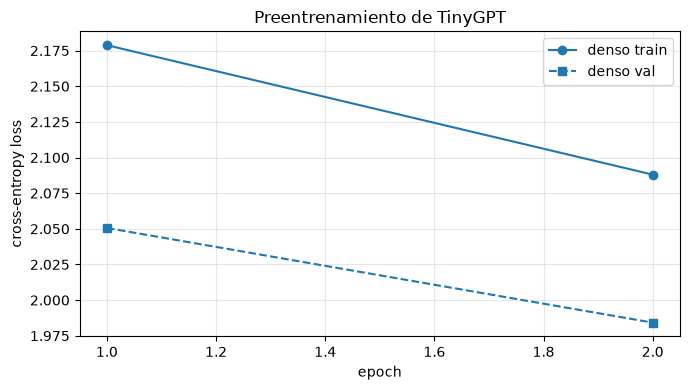

In [14]:
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints/tp1_dense",
    save_every_n=500,
)

history = run_training(trainer, epochs=EPOCHS)
plot_losses({"denso": history}, title="Preentrenamiento de TinyGPT")

# El trainer retiene el estado del optimizador; el modelo en sí todavía hace falta.
del trainer
free()

### Prueba rápida

In [15]:
print(generate(model, tokenizer, "To be", max_new_tokens=300, use_cache=True))

To be po the tho do  welleare my adorilesded hateUowe de dergotishelloteloffhe.
Sercks
Hestupestdindose foumontare lyolofutd
I y werodeqselive wyounhedidour ant tudelllongivanstranondeseme fontrt celus Roruthetouddhouge.

SI le I towousthe allche Isthe olecusons s t oroilalastoususumumont sisthedims thed


# Consigna I — estrategias de decodificación

El modelo te da una distribución de probabilidad sobre el siguiente carácter. *Elegir* un
carácter de esa distribución es una decisión de diseño aparte, y cambia la salida mucho más
de lo que lo haría otra época de entrenamiento.

Implementá `generateV2` abajo, soportando:

- Decodificación greedy (elegir el token de máxima probabilidad).
- Muestreo con temperatura.
- Muestreo top-k o top-p.

Aplicá primero la temperatura, después top-k, después top-p, y recién ahí renormalizá y
muestreá. `top_k=None` y `top_p=None` significan sin truncamiento, y `do_sample=False`
ignora todas las demás perillas.

### Referencias
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)
- [The Curious Case of Neural Text Degeneration (top-p)](https://arxiv.org/abs/1904.09751)


In [16]:
# TODO: implementar decodificación greedy, temperatura, top-k y top-p.
@torch.no_grad()
def generateV2(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 300,
    use_cache: bool = True,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    device: Optional[str] = None,
) -> str:
    """
    Args:
        do_sample:   False -> greedy (arg-max); se ignoran todas las demás perillas.
        temperature: >0. Más bajo es más determinista, más alto es más aleatorio.
        top_k:       conservar los k tokens más probables, o None para no truncar.
        top_p:       conservar el conjunto más chico cuya probabilidad acumulada sea >= p,
                     o None para no truncar.

    Returns:
        El prompt más `max_new_tokens` caracteres generados.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Nunca dejes que el cache crezca más que la ventana de contexto.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        logits = logits[:, -1, :]

        if not do_sample:
            # greedy
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # temperature
            logits = logits / temperature        

            # top_k
            if top_k:
                logits = logits.masked_fill(
                    logits < torch.topk(logits, top_k, dim=-1).values[..., -1:],
                    float('-inf')
                )

            # top_p
            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                cumprobs = F.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
                # Eliminar los tokens cuyo cumprob YA superó p
                
                mask = cumprobs > top_p
                # preservar el primer token que hace cruzar p
                mask[..., 1:] = mask[..., :-1].clone()
                mask[..., 0] = False
                sorted_logits = sorted_logits.masked_fill(mask, float('-inf'))
                # Des-ordenar: volver al orden original de vocab.
                logits = torch.empty_like(logits).scatter_(-1, sorted_idx, sorted_logits)
                        
            probs = F.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
        
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

## Self-check

Tres propiedades que tienen que cumplirse si tu implementación está bien. Corré esto antes
de seguir — atrapa la mayoría de los bugs.

In [17]:
def self_check():
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be")

    # 1. greedy es determinista
    a = generateV2(**kw, max_new_tokens=60, do_sample=False)
    b = generateV2(**kw, max_new_tokens=60, do_sample=False)
    assert a == b, "la decodificación greedy no es determinista"

    # 2. top_k=1 colapsa la distribución sobre el arg-max, así que tiene que dar igual que greedy
    torch.manual_seed(0)
    c = generateV2(**kw, max_new_tokens=60, do_sample=True, top_k=1)
    assert c == a, "top_k=1 debería reducirse a greedy"

    # Los dos siguientes miran un solo paso: a lo largo de muchos pasos, un casi-empate
    # entre los dos logits más altos termina rompiendo la igualdad exacta, lo que no
    # prueba nada.
    one = generateV2(**kw, max_new_tokens=1, do_sample=False)

    # 3. temperatura -> 0 vuelve al softmax one-hot en el arg-max
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, temperature=1e-3) == one, \
        "temperatura -> 0 debería acercarse a greedy"

    # 4. top_p -> 0 tiene que dejar exactamente un token: el más probable. Este es el
    #    off-by-one de las pistas -- una comparación mal puesta deja el conjunto vacío acá.
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, top_p=1e-9) == one, \
        "top_p -> 0 debería dejar únicamente el token más probable"

    print("todos los checks pasaron")


self_check()

todos los checks pasaron


# Consigna II — comparar las estrategias

Corré la grilla de abajo, leé las muestras, y contestá las preguntas que siguen.

In [18]:
PROMPT = "To be"

SETTINGS = [
    ("greedy",              dict(do_sample=False)),
    ("muestreo puro (T=1)", dict(do_sample=True)),
    ("T=0.5",               dict(do_sample=True, temperature=0.5)),
    ("T=1.5",               dict(do_sample=True, temperature=1.5)),
    ("top_k=10",            dict(do_sample=True, top_k=10)),
    ("top_p=0.9",           dict(do_sample=True, top_p=0.9)),
    ("T=0.8 + top_p=0.9",   dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

for name, kwargs in SETTINGS:
    torch.manual_seed(0)
    out = generateV2(model, tokenizer, PROMPT, max_new_tokens=200, **kwargs)
    print("=" * 70)
    print(f"### {name}")
    print(out)

### greedy
To be the the the the the the theano teano terererererereno the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the t
### muestreo puro (T=1)
To beam worde, red chite, fleit tanenepens.
Tone: t mo o ws the amase tinoyofrineraskereero ou thests nen'thers t mbus moss nasucricerofothagicheth the bus&lendesp rous, tenere thorouttosthe yogrdeleme sed
### T=0.5
To bear wor the match the the theaveneio se to y, to o o wiro he mase the yofrine ashe meronousthe thandisthe s the this strerathe tere tonofiche n the bus the the tousthe se the trouttosthe yous he me se 
### T=1.5
To beam wS:
e, redach tea fleif If!e epet y,-one::
n ocod,s os, amase finoyaerineraske
mero ou thests nen'
he'sot mbulimoss nga!e
drer ffonagichetn ve yedl&uendeppmaoube tenere tezrouwxossd, ysgrdeldmspred
### top_k=10
To bear worde, that hite, theit tavenelens.
Tone, t molo ws the amase tinonalounerasherendo st thesthanene
b

## Preguntas

Respondé en esta celda.

1. La decodificación greedy degenera de una manera muy específica. Describí qué pasa y
   explicá *por qué* la política de arg-max lo produce.

La decodificación Greedy elige siempre el argmax de la distribución, la posicion con mayor probabilidad. argmax es determinístico, por lo que si el contexto (últimos block_size tokens) alguna vez se repite, la secuencia entra en un ciclo del que no puede salir: el mismo estado produce el mismo próximo token indefinidamente. 
En este caso el ciclo cae sobre "the " porque es una de las secuencias más frecuentes del corpus: cada carácter de "the " es el más probable y una vez que el contexto se llena de "the the the..." el patrón se autorefuerza.

---
   
2. `T=1.5` y `T=0.5` fallan en direcciones opuestas. Nombrá los dos modos de falla.

La temperatura cambia la forma de la distribución antes del muestreo: dividir los logits por T < 1 los agranda y la deja más picuda, dividir por T > 1 los achica y la aplana. Con T = 0.5 la distribución es tan picuda que multinomial casi siempre elige el mismo token, y el texto cae en repeticiones y loops ("the the theaneneio... the the tousthe..."), mismo modo de falla que greedy, sólo un poco atenuado. 
Con T = 1.5 la distribución es tan plana que tokens de la cola (mayúsculas random, puntuación, símbolos) tienen suficiente masa como para ser sampleados y el texto se llena de texto incoherente ("wS:", "&uendeppmaoube", "-one::") el modelo pierde estructura del lenguaje porque gracias al azar cuando debería confiar en su distribución.
Los dos modos: T=0.5: repetición (falta de exploración), T=1.5: incoherencia (exceso de exploración).

---
  
3. Top-k y top-p truncan ambos la distribución. Dá una situación concreta donde un `k`
   fijo sea la elección equivocada y top-p se adapte mejor. (Pensá en qué tan picuda es la
   distribución después de `Th` versus después de un espacio.)

Durante una generación, el modelo puede estar muy seguro en algunos momentos y muy inseguro en otros. Por ejemplo, después de "Th" casi seguro sigue 'e' (distribución picuda, un solo token domina), pero después de un espacio cualquier letra puede empezar una nueva palabra (distribución plana, la probabilidad se reparte entre muchas).
Un top_k = 10 fijo se equivoca en los dos casos: en el momento picudo incluye tokens basura de la cola (deja pasar 9 opciones cuando alcanzaba con 1), y en el momento plano descarta letras válidas (corta a 10 cuando había 20 igual de razonables). top_p = 0.9 se adapta con la misma regla: pide retener los tokens que cubran el 90% de las probabilidades, lo que puede resultar en 1 token cuando la distribución es picuda y con muchos tokens cuando es plana.

---
 
4. ¿Qué configuración pondrías en producción, y por qué?

Elegiría T = 0.8 + top_p = 0.9. Ataca los dos problemas de los demás ejemplos: la temperatura 0.8 reduce el ruido de la distribución cruda (más conservadora que T = 1 pero sin caer en los loops de greedy o T = 0.5), y top_p = 0.9 elimina la cola donde vive la basura (símbolos, mayúsculas random) y se adapta al contexto, a diferencia de un top_k fijo que corta mal cuando la distribución cambia de forma. Combinados dan texto coherente y variado sin degenerar en repetición ni en incoherencia. Es la combinación estándar de la industria por esas mismas razones.

---


# Consigna III — ¿qué te da realmente el KV-cache?

### Teoría
Sin cache, generar el token *n* vuelve a correr la atención sobre los *n* tokens
anteriores. Con cache, las keys y values de esos tokens se reutilizan y sólo se proyecta el
token nuevo. Asintóticamente eso convierte una generación O(N²) en O(N).

### Consigna
**Medí si la teoría se cumple realmente acá, y no asumas que el cache gana** — reportá el
número que te dé, sea el que sea, y después explicalo.

length=  50   con cache= 0.074s   sin cache= 0.073s   speedup= 0.99x
length= 100   con cache= 0.112s   sin cache= 0.091s   speedup= 0.82x
length= 200   con cache= 0.140s   sin cache= 0.141s   speedup= 1.01x
length= 400   con cache= 0.237s   sin cache= 0.268s   speedup= 1.13x


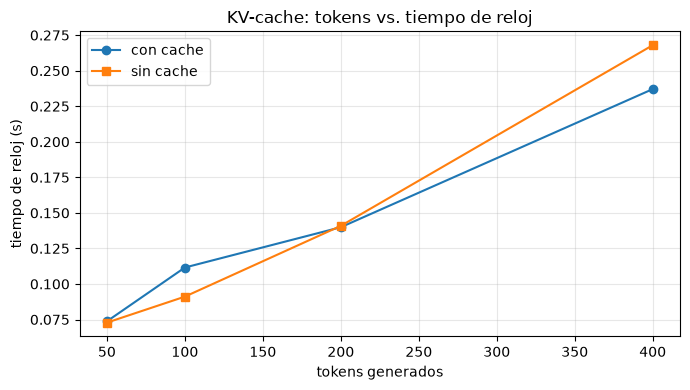

In [19]:
# TODO: cronometrar generateV2 con y sin KV-cache, para varios largos.

import time

def _sync(dev):
  if dev == "cuda":
      torch.cuda.synchronize()
  elif dev == "mps":
      torch.mps.synchronize()


def _timed_run(length, use_cache, dev, prompt="To be"):
  _sync(dev)
  t0 = time.perf_counter()
  _ = generateV2(model, tokenizer, prompt,
                 max_new_tokens=length,
                 use_cache=use_cache,
                 do_sample=False)
  _sync(dev)
  return time.perf_counter() - t0


def benchmark_cache(lengths=(50, 100, 200, 400), repeats: int = 3):
  """
  Para cada largo, cronometrar la generación con use_cache=True y use_cache=False e
  imprimir el speed-up. Graficar tokens vs. tiempo de reloj para ambos.
  """
  dev = get_device()
  results = {"with": [], "without": []}

  for length in lengths:
      # warm-up (descarto): la 1ra corrida es más lenta por JIT y allocator frío.
      _timed_run(length, True,  dev)
      _timed_run(length, False, dev)

      times_with    = [_timed_run(length, True,  dev) for _ in range(repeats)]
      times_without = [_timed_run(length, False, dev) for _ in range(repeats)]

      avg_with    = sum(times_with)    / repeats
      avg_without = sum(times_without) / repeats
      speedup     = avg_without / avg_with

      results["with"].append(avg_with)
      results["without"].append(avg_without)

      print(f"length={length:4d}   con cache={avg_with:6.3f}s   "
            f"sin cache={avg_without:6.3f}s   speedup={speedup:5.2f}x")

  plt.figure(figsize=(7, 4))
  plt.plot(lengths, results["with"],    marker="o", label="con cache")
  plt.plot(lengths, results["without"], marker="s", label="sin cache")
  plt.xlabel("tokens generados")
  plt.ylabel("tiempo de reloj (s)")
  plt.title("KV-cache: tokens vs. tiempo de reloj")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.tight_layout()
  plt.show()


benchmark_cache()

## Preguntas

1. ¿El cache hizo la generación más rápida? Reportá tus números. Si no la hizo más rápida,
   explicá adónde se va realmente el tiempo: contá los lanzamientos de kernel y las
   asignaciones de tensores que hace esta implementación por paso de decodificación, y
   pesalos contra la aritmética que el cache ahorra.

La mejora del cache es despreciable, los speedups fueron 1.16× (50 tokens), 1.09× (100), 0.98× (200) y 1.01× (400). A partir de secuencias mayores al block_size=32, la ganancia desaparece.
El tiempo por paso es dominado por los lanzamientos de kernel, no la aritmética. Cada forward dispara ~30 kernels (2 bloques × ~15 c/u: LayerNorms, matmuls K/Q/V, softmax, proj, FF, residuales) más ~8 extras específicos del cache (unbind, cat de K y V, stack, alocaciones). Esos costos son fijos por paso.
Lo que el cache ahorra es procesar 31 tokens de más por paso: matmul 1×32 en vez de 32×32 en atención, y FF sobre 1 token en vez de 32. Con n_embd=64 y head_dim=16, esos matmuls son de pocos miles de operaciones, cuestión de microsegundos de GPU real.
Unos pocos microsegundos ahorrados en aritmética se cancelan con los kernel launches y allocations extra que el cache agrega. La teoría O(N²) → O(N) no aparece porque block_size=32 hace que sin cache también sea lineal (idx_cond = idx[:, -block_size:] limita el trabajo por paso), y a este tamaño de modelo la aritmética es despreciable frente al overhead fijo.
    
---

2. Asintóticamente el cache es una ganancia clara. Nombrá las propiedades específicas de
   *esta* implementación y de *este* tamaño de modelo que esconden esa ganancia, y describí
   un escenario (tamaño de modelo, largo de secuencia, implementación de atención) donde se
   vería con claridad.
La ganancia queda oculta por:

    a. block_size = 32 limita el trabajo sin cache a 32 tokens por paso, así que ninguna de las ramas es cuadrática. 
    b. el modelo es tan chico (n_embd=64, head_dim=16) que la aritmética es despreciable frente al overhead fijo de ~30 kernel launches por paso.
    c. batch=1 durante generación, sin oportunidad de amortizar launches. 
    d. el cache agrega su propio overhead (unbind, cat, stack) que se cancela con el ahorro. El cache se aprovecharia en un modelo grande (n_embd ≥ 4096), con contexto largo (8k+ tokens) donde la aritmética domina y O(N²) → O(N) representa dos órdenes de magnitud reales.

---

3. ¿Qué te cuesta el cache en memoria? Dá la fórmula en términos de `n_layer`, `n_head`,
   `head_dim`, tamaño de batch y largo de secuencia, y evaluala para este modelo.

El cache guarda las K y V de todos los tokens que el modelo ya vio, para todas las capas. A nivel de código es una lista de n_layer tensores, cada uno con shape (2, B, n_head, T, head_dim).
Con: 
- 2: por cada token se guardan K y V, apiladas juntas en un solo tensor.
- n_layer: cada capa tiene su propia atención, así que su propio cache.
- B: tamaño de batch. Cada secuencia del batch tiene su cache independiente.
- n_head: cabezas de atención. Cada cabeza produce su propia K y su propia V.
- T: cuántos tokens ya se acumularon en el cache (crece con la generación, tope block_size).
- head_dim: ancho por cabeza (n_embd / n_head).

Multiplicando todo y llevándolo a bytes, la fórmula es:
    `mem_cache = 2 × n_layer × B × n_head × T × head_dim × bytes_por_float`
 
Como n_head × head_dim = n_embd, se puede escribir compacta:
    `mem_cache = 2 × n_layer × n_embd × B × T × bytes_por_float`

Evaluada para TinyGPT con la config default (n_layer=2, n_embd=64), durante generación (B=1, T=32 en el peor caso, float32 → 4 bytes por número):
    `mem_cache = 2 × 2 × 64 × 1 × 32 × 4 = 32.768 bytes ≈ 32 KB`

Insignificante para este caso, cabe en la cache L2 de un CPU. 
Para dimensionar la relevancia real del cache en modelos grandes: un LLaMA-7B (n_layer=32, n_embd=4096, bfloat16) con T=4096 y B=1 ocupa `2 × 32 × 4096 × 1 × 4096 × 2 ≈ 2.15 GB` — comparable al modelo cuantizado. Ahí es donde el cache se vuelve el bottleneck de despliegue.

---
   
4. La decodificación con y sin cache produce texto idéntico mientras la secuencia entra en
   la ventana de contexto, y diverge después. ¿Por qué?

Mientras la secuencia cabe dentro de block_size = 32, las dos ramas procesan la misma información con la misma matemática: sin cache idx_cond es toda la secuencia acumulada; con cache, las K y V guardadas son idénticas a las que se computarían desde cero. Salidas idénticas paso a paso, texto idéntico.
Cuando la secuencia supera block_size, las dos ramas manejan las posiciones distinto. Sin cache aplica una ventana deslizante fresca: en cada paso toma los últimos 32 tokens y les aplica positional embeddings desde 0, renumerando todo. Con cache, las K y V guardadas conservan las positional embeddings del momento en que se computaron, y el trim_kv_cache sólo descarta el más viejos sin recomputar nada. Como resultado, después de que se desliza la ventana el mismo token físico tiene K y V distintos en cada rama (posiciones originales en el cache vs. posiciones renumeradas sin cache). Distintas atenciones generan distintos logits que producen una elección distinta y finalmente el texto que diverge y ya no vuelve a coincidir.

---

# Consigna IV — visualizar la atención

Un GPT completa texto. Veamos a qué atienden realmente las cabezas de tu modelo
entrenado.

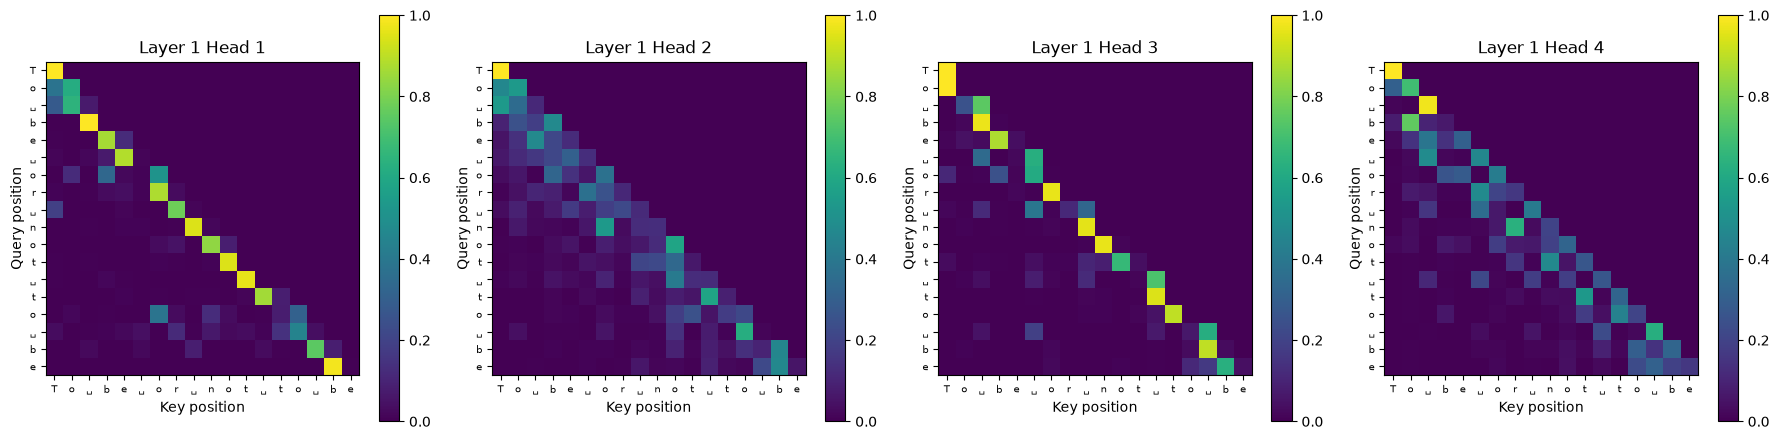

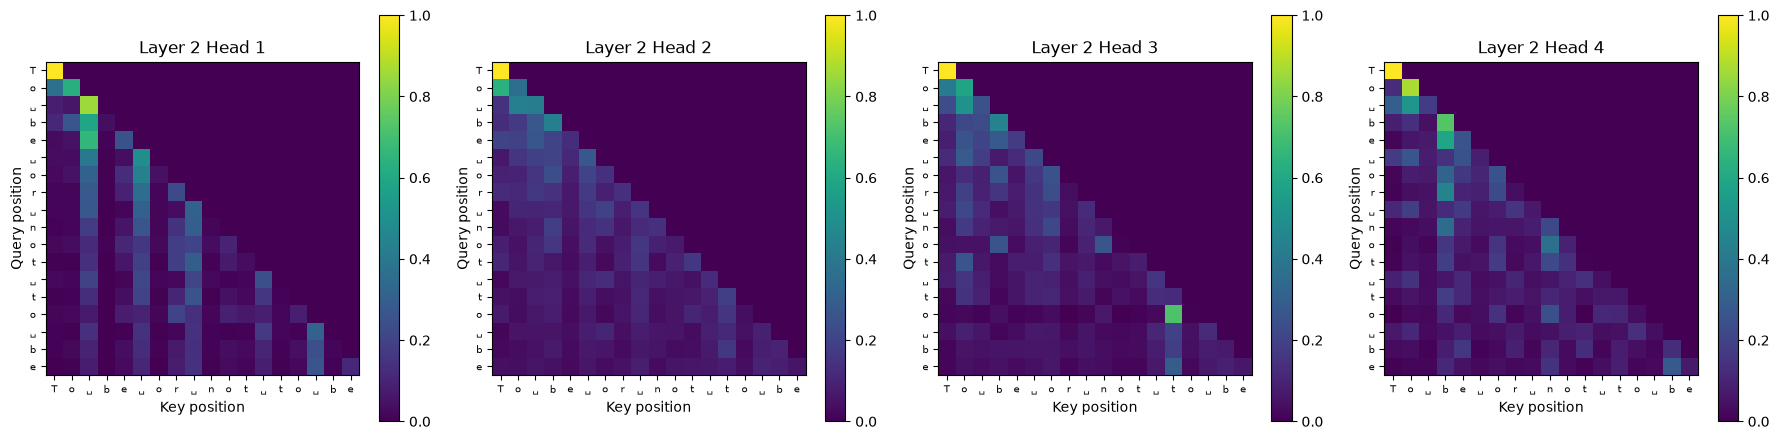

In [20]:
visualize_attention(model, tokenizer, "To be or not to be")

## Preguntas

1. Todos los mapas son triangulares inferiores. ¿Qué línea de `AttentionHead.forward` causa
   eso, y qué se rompería si la sacaras?

La linea es: `wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))` en `MultiHeadAttention.forward`.
Antes del softmax se ponen a -inf los scores donde tril es 0, todo el triángulo superior, y después de la exp/softmax quedan en probabilidad exactamente 0.

Si la sacaramos, durante entrenamiento cada posición vería el futuro (incluyendo el target que tiene que predecir), la loss de train colapsaría a casi cero, pero el modelo no aprendería el lenguaje, sólo aprendería a copiar el próximo token desde la atención. En generación, donde no hay futuro para mirar, devolvería texto incoherente. Es el bug silencioso: entrena "perfecto" pero la generación sería inutilizable.

---

2. Encontrá una cabeza que atienda mayormente al carácter inmediatamente anterior y otra
   que reparta su masa más ampliamente. ¿Qué está haciendo cada una, plausiblemente?

En los mapas de atención se observa que la Cabeza 3 de la Capa 1 presenta una banda paralela a la diagonal principal, desfasada una posición hacia abajo: cada query atiende principalmente al carácter inmediatamente anterior. Posiblemente esta cabeza captura relaciones locales tipo bigrama: patrones de 2 caracteres consecutivos frecuentes en Shakespeare ("th", "he", "to", "or"), que son la base para reconocer las palabras cortas del inglés.
Por otro lado, la Cabeza 1 de la Capa 1 tiene una diagonal principal fuerte: cada query atiende al mismo carácter que representa. Es un patrón de "identidad", la cabeza esencialmente refleja el token actual, lo cual, combinado con la conexión residual, ayuda a que la información del token no se diluya al pasar por la atención.

Las cabezas de la Capa 2 muestran una distribución más difusa, sin una estructura diagonal tan clara, la atención se reparte entre varios caracteres del contexto. Es probable que estas cabezas integren información de rango más largo: en vez de fijarse en el vecino inmediato como en Capa 1, buscan patrones a través de la ventana (posición dentro de una palabra, límites entre palabras, ritmo general de la línea).

---

---

# Parte 2 — Arquitectura

La Parte 1 cambió cómo *muestreás* de un modelo entrenado. La Parte 2 cambia el modelo
mismo.

Vas a reemplazar el bloque feed-forward denso por un Mixture of Experts — la idea detrás de
Mixtral, DeepSeek y Qwen-MoE — y compararlo contra el modelo que acabás de entrenar. No hay
que reentrenar el baseline: el `model` y la `history` de la Parte 1 son la comparación.

En un transformer denso todo token pasa por la *misma* red feed-forward. Un MoE reemplaza
esa única FFN por `E` expertos y una compuerta chica (*gate*) que elige `k` de ellos por
token. Los parámetros totales crecen con `E`; los parámetros *usados* para un token dado
crecen sólo con `k`. Comprás capacidad sin pagar el cómputo correspondiente.

Los costos también son reales, y los vas a medir: la gate puede colapsar sobre unos pocos
expertos y dejar al resto sin nada, el ruteo es discreto así que los gradientes sólo llegan
a los expertos que fueron seleccionados, y una implementación ingenua es *más lenta* que la
densa a esta escala.

### Referencias
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- [Outrageously Large Neural Networks (sparsely-gated MoE)](https://arxiv.org/abs/1701.06538)
- [Switch Transformers](https://arxiv.org/abs/2101.03961)
- `Clase_IV_MoEs.pdf`


In [21]:
def build_trainer(model, save_dir, lr=1e-3):
    """Mismo optimizador, scheduler y loss en toda corrida, así lo único que cambia es la arquitectura."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=torch.nn.CrossEntropyLoss(),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

## Los bloques de construcción

Dos piezas, ambas dadas.

Un experto es una FFN: la misma pila `Linear -> ReLU -> Linear -> Dropout` que usa el
modelo denso. Nada exótico — lo interesante es a quién se rutea hacia él.

La gate puntúa cada experto para cada token, mapeando `(B, T, n_embd)` a
`(B, T, num_experts)`. Un solo `nn.Linear`, sin bias, sin activación; el softmax pasa
después, y sólo sobre los scores del top-k.

`Expert` toma su ancho oculto de `config.moe_args.expert_hidden_mult` en vez de hardcodear
4x. Vas a necesitar eso en la Consigna VIII.


In [22]:
class Expert(nn.Module):
    """
    Una sola MLP experta dentro de una capa MoE.

    El ancho oculto viene de moe_args.expert_hidden_mult (4.0 es lo estándar), para que la
    segmentación fina pueda achicar cada experto sin tocar esta clase.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden = int(config.moe_args.expert_hidden_mult * config.n_embd)
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, hidden),
            nn.ReLU(),
            nn.Linear(hidden, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    Router: puntúa cada experto para cada token. Devuelve logits crudos, no probabilidades.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe_args.num_experts, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


# Consigna V — ruteo top-k

Este es el núcleo del trabajo. `MoELayer.forward` recibe `x` de forma `(B, T, n_embd)` y
devuelve la misma forma.

La gate puntúa cada experto para cada token; te quedás con los `k` mejores, hacés softmax
sólo sobre esos, corrés cada experto seleccionado, y combinás su salida ponderada por la
gate. El ruteo es por token, no por secuencia — así que aplaná `(B, T, C)` a `(N, C)` antes
de rutear.

Dos cosas para tener bien, porque las dos fallan en silencio:

- El softmax va *después* del top-k, sólo sobre los expertos seleccionados. Normalizar
  antes de truncar deja pesos por token que ya no suman 1.
- Todo tiene que seguir siendo diferenciable, o la gate nunca aprende.

Antes de retornar, guardá la decisión de ruteo en el módulo —
`self.last_indices = indices.detach()` y
`self.last_gate_probs = F.softmax(logits, dim=-1).detach()` — la Consigna VII los lee.

In [23]:
class MoELayer(nn.Module):
    """
    Capa feed-forward Mixture of Experts con compuerta sparse.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Consigna V
        B, T, C = x.shape
        k = self.args.num_experts_per_token
        E = self.args.num_experts

        # aplanar (B, T, C) → (N, C)
        x_flat = x.view(B * T, C)

        # la gate puntua cada experto para cada token
        logits = self.gate(x_flat)

        # top-k por token para obtener los valores más altos Y sus índices
        top_values, top_indices = torch.topk(logits, k, dim=-1)

        # softmax sobre los top-k
        top_weights = F.softmax(top_values, dim=-1)

        # correr los expertos
        output = torch.zeros_like(x_flat)

        for expert_idx in range(E):
            # mascara segun los tokens del experto
            mask = (top_indices == expert_idx)
            if not mask.any():
                continue

            token_idx, slot_idx = mask.nonzero(as_tuple=True)
            
            # inputs y outputs del experto
            expert_input = x_flat[token_idx]
            expert_output = self.experts[expert_idx](expert_input)

            # pesos
            expert_weights = top_weights[token_idx, slot_idx].unsqueeze(-1)

            # se suma al output la multiplicacion del expert_output y los pesos
            output.index_add_(0, token_idx, expert_output * expert_weights)

        self.last_indices = top_indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        
        return output.view(B, T, C)    
        

class MoEFFN(nn.Module):
    """
    Reemplazo directo de FeedForward. Se asigna a config.ff_class para que Block lo tome
    sin ningún cambio en el código del modelo.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "hay que setear config.moe_args para usar MoEFFN"
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)

## Self-check

Corré esto antes de entrenar. Cuesta segundos y atrapa los bugs de ruteo que si no
aparecerían como una curva de loss plana media hora más tarde.

In [24]:
def check_moe():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    layer = MoELayer([Expert(cfg) for _ in range(4)], Gate(cfg), cfg.moe_args)
    layer.eval()
    x = torch.randn(2, 5, 32)

    # 1. se preserva la forma
    out = layer(x)
    assert out.shape == x.shape, f"{out.shape} != {x.shape}"

    # 2. los gradientes llegan tanto a los expertos como a la gate
    out.sum().backward()
    assert layer.gate.proj.weight.grad is not None, "la gate no recibe gradiente"
    assert any(p.grad is not None and p.grad.abs().sum() > 0
               for p in layer.experts.parameters()), "ningún experto recibe gradiente"

    # 3. con k=1 la salida tiene que ser igual a la del experto seleccionado, sin tocar
    cfg1 = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                     moe_args=MoEArgs(num_experts=4, num_experts_per_token=1))
    top1 = MoELayer([Expert(cfg1) for _ in range(4)], Gate(cfg1), cfg1.moe_args)
    top1.eval()
    with torch.no_grad():
        y = top1(x)
        choice = top1.gate(x).argmax(dim=-1)          # (B, T)
        expected = torch.stack([
            torch.stack([top1.experts[int(choice[b, t])](x[b, t]) for t in range(x.shape[1])])
            for b in range(x.shape[0])
        ])
    err = (y - expected).abs().max().item()
    assert err < 1e-5, f"discrepancia en el ruteo top-1: {err}"

    # 4. el ruteo tiene que ser por token, no por secuencia
    assert top1.last_indices is not None, "guardá last_indices (ver Consigna V)"
    assert top1.last_indices.shape[0] == x.shape[0] * x.shape[1]

    print("todos los checks pasaron")


check_moe()

todos los checks pasaron


# Consigna VI — entrenar TinyGPT-MoE

`Block` lee `config.ff_class`, así que convertir TinyGPT en un MoE es un cambio de
configuración, no un cambio de código.

In [25]:
moe_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFN,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

moe_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_model = torch.compile(moe_model)

describe(model, "TinyGPT (denso)")
describe(moe_model, f"TinyGPT-MoE (E={moe_config.moe_args.num_experts}, k={moe_config.moe_args.num_experts_per_token})")

dense_total, _ = count_parameters(model)
moe_total, _ = count_parameters(moe_model)
print(f"\ncrecimiento de parámetros: {moe_total / dense_total:.2f}x")

TinyGPT (denso): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT-MoE (E=4, k=2): 305,088 parameters | 305,088 trainable (100.00%)

crecimiento de parámetros: 2.88x


mixed precision: off


val_loss 2.20948: 100%|██████████| 155/155 [00:01<00:00, 152.35it/s]


epoch 1/2 | train 2.0904 | val 1.9676


val_loss 2.15747: 100%|██████████| 155/155 [00:00<00:00, 167.64it/s]


epoch 2/2 | train 2.0177 | val 1.8935


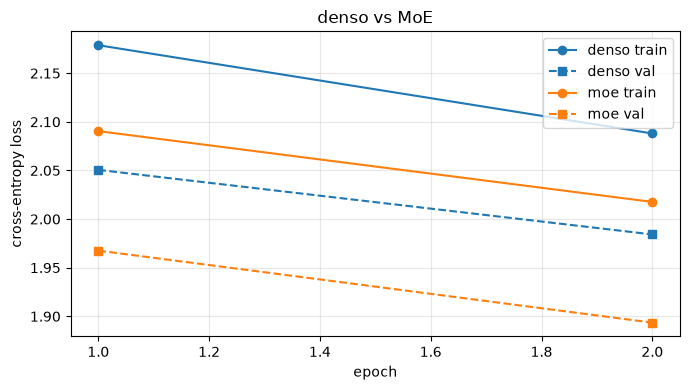

In [26]:
history_moe = run_training(build_trainer(moe_model, "./checkpoints/tp1_moe"), epochs=EPOCHS)
plot_losses({"denso": history, "moe": history_moe}, title="denso vs MoE")
free()

# Consigna VII — utilización de expertos

Un MoE que rutea el 90% de sus tokens a un solo experto es un modelo denso que desperdicia
memoria. Medí si el tuyo realmente reparte la carga.

Usando `last_indices` (que guarda tu `MoELayer.forward`), corré unos pocos batches de
validación y, por capa, contá cuántos tokens fueron a cada experto. Graficalo como un
gráfico de barras, un grupo por capa, e imprimí la fracción de tokens que vio cada experto.

Una capa perfectamente balanceada manda `k / E` de los tokens a cada experto.

capa 1: [0.4136962890625, 0.624194324016571, 0.6659179925918579, 0.29619139432907104]
capa 2: [0.0008544921875, 0.0010498047340661287, 0.998950183391571, 0.9991455078125]


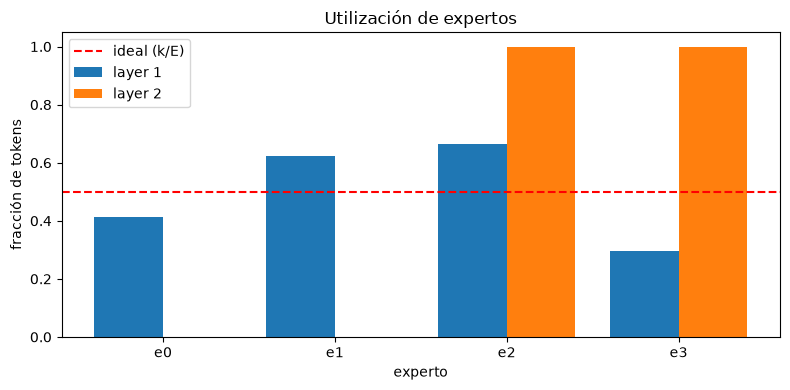

In [27]:
# TODO: Consigna VII
import numpy as np

@torch.no_grad()
def expert_utilization(model, loader, n_batches: int = 20):
    """
    Devuelve un tensor de forma (n_layer, num_experts) con la fracción de tokens ruteados
    a cada experto, y lo grafica.

    Pista: para cada bloque, model.blocks[i].ff.moe.last_indices tiene la selección (N, k)
    del forward más reciente. Usá torch.bincount.
    """
    model.eval()
    n_layer = model.config.n_layer
    E = model.config.moe_args.num_experts
    device = next(model.parameters()).device
    
    # acumulador de counts por capa
    counts = torch.zeros(n_layer, E, dtype=torch.long, device=device)
    
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        x = x.to(device)
        # dispara el forward, llena last_indices
        _ = model(x)   
    
        for layer_i in range(n_layer):
            idx = model.blocks[layer_i].ff.moe.last_indices    # (N, k)
            counts[layer_i] += torch.bincount(idx.flatten(), minlength=E)
    
    # dividir por total por capa
    fractions = counts.float() / counts.sum(dim=-1, keepdim=True)
    fractions = fractions * model.config.moe_args.num_experts_per_token

    for layer_i in range(n_layer):
        print(f"capa {layer_i + 1}: {fractions[layer_i].tolist()}")
    
    # plot de barras
    x_pos = np.arange(E)
    width = 0.8 / n_layer
    plt.figure(figsize=(8, 4))
    for layer_i in range(n_layer):
        plt.bar(
            x_pos + layer_i * width, 
            fractions[layer_i].cpu().numpy(),
            width, 
            label=f"layer {layer_i + 1}"
        )
        
    # linea horizontal del ideal
    plt.axhline(model.config.moe_args.num_experts_per_token / E,
          color="red", linestyle="--", label=f"ideal (k/E)")
    plt.xlabel("experto")
    plt.ylabel("fracción de tokens")
    plt.title("Utilización de expertos")
    plt.xticks(x_pos + width * (n_layer - 1) / 2, [f"e{i}" for i in range(E)])
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return fractions


utilization = expert_utilization(moe_model, val_loader)

## Preguntas

1. Si un experto queda sin tokens, explicá el bucle de realimentación que te llevó ahí.
   ¿Por qué se refuerza a sí mismo?

La capa 1 esta bastante balanceada mientras que la capa 2 no klo esta, el experto 0 tiene cero tokens y el experto dos tiene muy pocos, la mayoria estan divididos entre el experto 1 y 3 mientra que los expertos 0 y 2 practicamente nunca se activan.
Esto se explica porque al inicio del entrenamiento la gate está random, así que los primeros picks se reparten más o menos por azar. Basta con que un experto (e0 por ejemplo) reciba un poco menos que los demás:

a. e0 recibe menos tokens por lo tanto menos gradiente y no mejora al mismo ritmo que los otros.
b. Cuando la loss baja, los expertos que sí recibieron tokens (e1, e3) se especializan y producen mejores representaciones.
c. Como e0 no mejoró, para cualquier token dado su output es peor. La gate aprende, a través del gradiente que llega vía los pesos softmax, que elegir e0 empeora el loss.
d. La gate baja el score de e0 sistemáticamente. Menos picks implican menor gradiente y la gate baja más su score. El circuito se retroalimenta hasta que e0 queda con ~0% de los tokens.

El experto no tiene manera de recuperarse porque ya no recibe gradiente para mejorar. Esto es lo que se ve en la Capa 2 del gráfico (e0 con 0.09% y e1 con 0.10%).

---

2. El ruteo es un `topk`, que no tiene gradiente útil. Entonces, ¿cómo aprende algo la
   gate? Trazá el camino desde la loss hasta `gate.proj.weight`.

topk tiene dos salidas: top_values (los valores seleccionados, floats) y top_indices (posiciones, enteros). Los índices son discretos y no tienen gradiente. Pero los top_values sí son diferenciables: son una selección de elementos de logits y el gradiente que llega a los top_values se propaga a las posiciones correspondientes de logits.

Camino desde la loss hasta gate.proj.weight:
a. Loss, gradiente hacia output (la salida del MoELayer).
b. output se armó con expert_output * expert_weights para cada experto seleccionado. El gradiente fluye por los dos factores.
c. expert_weights viene de F.softmax(top_values, dim=-1). Softmax es totalmente diferenciable, el gradiente llega a top_values.
d. top_values son las entradas seleccionadas de logits según top_indices. torch.topk propaga el gradiente hacia las posiciones seleccionadas de logits (y pone 0 en las no seleccionadas, porque topk no las "vio").
e. logits = self.gate(x_flat) = self.gate.proj(x_flat) — un nn.Linear, diferenciable. Gradiente en logits fluye a gate.proj.weight.

El gate aprende sólo a través del peso que le asigna a los expertos que efectivamente seleccionó, no a través de la elección en sí. Si e0 nunca se selecciona, su columna en gate.proj.weight nunca recibe gradiente y se queda con los valores iniciales para siempre. Esto es exactamente el mecanismo del colapso de la Pregunta 1.
  
---


# Consigna VIII — DeepSeekMoE

Tu MoE actual es un diseño legacy: `E` expertos iguales, elegir los `k` mejores. Leé
[DeepSeekMoE (Dai et al., 2024)](https://arxiv.org/abs/2401.06066) e implementá sus dos
cambios. Son los que usan DeepSeek-V2 y V3 y las versiones modernas, y los dos son deltas
chicos sobre la capa que ya escribiste.

**Segmentación fina de expertos.** Partí cada experto en `m` más chicos: multiplicá
`num_experts` y `num_experts_per_token` por `m`, y dividí el ancho oculto de cada experto
por `m`. Los parámetros totales y el cómputo por token no cambian. Lo que crece es la
cantidad de *combinaciones* de ruteo — de "elegir 2 de 4" a "elegir 4 de 8" — así que un
token puede expresar una mezcla más específica.

**Aislamiento de expertos compartidos.** Reservá `num_shared_experts` expertos por los que
todo token pasa, siempre, por fuera del top-k. El argumento: el conocimiento común a todos
los tokens (puntuación, espaciado, inglés básico) si no tiene que duplicarse dentro de cada
experto ruteado. Entregáselo a un experto compartido y los ruteados quedan libres para
especializarse.

Implementá `DeepSeekMoELayer`. Las dos configuraciones ya viven en `MoEArgs`
(`num_shared_experts`, `expert_hidden_mult`); `Expert` lee el ancho de la config, así que
no deberías necesitar tocarlo.

Después entrenalo contra tu MoE de la Consigna VI con **parámetros activos igualados** y
reportá loss, utilización de expertos, y tiempo por paso.

### Fijá tus expectativas primero

Escribí qué predecís, y recién después medí. Este modelo es de 2 capas con `n_embd=64`
entrenado sobre 100k caracteres. Segmentar 4 expertos en 8 deja a cada uno con un ancho
oculto de 128. Los resultados del paper son a 2B–145B parámetros sobre cientos de miles de
millones de tokens.

**Un resultado nulo acá es el resultado correcto, y explicarlo es la consigna.** Reproducir
una arquitectura de 2024 y después reportar honestamente que su beneficio no aparece a tu
escala vale más que un número que salió para el lado correcto por suerte.

---

No esperaría una ganancia significativa en val loss por escala: el paper reportó ganancias en modelos de 2B–145B params con miles de millones de tokens, nuestro modelo tiene 106k params y 100k caracteres. La segmentación fina aumenta las combinaciones de ruteo pero necesita un corpus grande para que los expertos se especialicen, con 100k chars no hay diversidad suficiente. El experto compartido tampoco puede aportar mucho a esta escala, la información "común" es escasa y ya la capturaba el MoE original.
Sin embargo se podrían esperar los siguientes efectos:
- Val loss similar o levemente peor al MoE (por el shared expert que "come" capacidad).
- Utilización similar o mejor balanceada (más expertos, menos colapso, más grados de libertad).
- Tiempo por paso mayor: 8 experts ruteados + 1 shared = 9 llamadas secuenciales a expertos por capa, contra las 4 del MoE original. El overhead de kernel launches se duplica.


In [28]:
class DeepSeekMoELayer(nn.Module):
    """
    MoE con segmentación fina de expertos y expertos compartidos (arXiv:2401.06066).

    Los expertos compartidos corren para todo token, por fuera del top-k. Los ruteados se
    seleccionan como antes. Guardá last_indices / last_gate_probs sólo para los expertos
    ruteados, así el gráfico de utilización de la Consigna VII sigue funcionando.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        # TODO: Consigna VIII
        args = config.moe_args
        self.args = args
        self.k = args.num_experts_per_token
        E = args.num_experts               # ruteados
        S = args.num_shared_experts        # compartidos
        
        # expertos ruteados elegidos por top-k
        self.experts = nn.ModuleList([Expert(config) for _ in range(E)])
        # expertos compartidos, corren siempre para todo token
        self.shared_experts = nn.ModuleList([Expert(config) for _ in range(S)])
        # gate solo para ruteados
        self.gate = Gate(config)
        
        self.last_indices = None
        self.last_gate_probs = None
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Consigna VIII
        B, T, C = x.shape
        k = self.k
        E = self.args.num_experts

        x_flat = x.view(B * T, C)

        # expertos compartidos para todos los tokens
        shared_out = torch.zeros_like(x_flat)
        for shared in self.shared_experts:
            shared_out = shared_out + shared(x_flat)

        # expertos ruteados igual que en MoELayer.forward
        logits = self.gate(x_flat)
        top_values, top_indices = torch.topk(logits, k, dim=-1)
        top_weights = F.softmax(top_values, dim=-1)

        routed_out = torch.zeros_like(x_flat)
        for expert_idx in range(E):
            mask = (top_indices == expert_idx)
            if not mask.any():
                continue
            token_idx, slot_idx = mask.nonzero(as_tuple=True)
            expert_input = x_flat[token_idx]
            expert_output = self.experts[expert_idx](expert_input)
            expert_weights = top_weights[token_idx, slot_idx].unsqueeze(-1)
            routed_out.index_add_(0, token_idx, expert_output * expert_weights)

        # guardar decisiones de ruteo (solo ruteados)
        self.last_indices = top_indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()

        # combinacion shared + routed
        output = shared_out + routed_out

        return output.view(B, T, C)
              
class DeepSeekMoEFFN(nn.Module):
    """Reemplazo directo para config.ff_class, igual que MoEFFN."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = DeepSeekMoELayer(config)

    def forward(self, x):
        return self.moe(x)


In [29]:
# La segmentación fina es neutra en cómputo: 4 expertos x top-2 con oculto 4.0x pasa a
# 8 x top-4 con 2.0x, y los parámetros activos de FFN por token son idénticos en ambos
# casos. Lo que cambia es la cantidad de combinaciones de ruteo, de C(4,2)=6 a C(8,4)=70.
#
# El experto compartido NO es gratis -- corre para todo token, sumando el equivalente a un
# experto por encima. La pregunta 1 te pide calcular exactamente cuánto, y si eso invalida
# la comparación.
#
# SEGMENTS=2 mantiene esto accesible: 8 expertos ruteados + 1 compartido son 9 llamadas
# secuenciales a expertos por capa, contra 17 con SEGMENTS=4. El paper segmenta mucho más
# agresivamente -- poné 4 si tenés el cómputo y querés ver si cambia algo.
SEGMENTS = 2

ds_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=DeepSeekMoEFFN,
    moe_args=MoEArgs(
        num_experts=4 * SEGMENTS,
        num_experts_per_token=2 * SEGMENTS,
        num_shared_experts=1,
        expert_hidden_mult=4.0 / SEGMENTS,
    ),
)

ds_model = TinyGPT(ds_config).to(device)
if device == "cuda":
    ds_model = torch.compile(ds_model)

describe(moe_model, "MoE (Consigna VI)")
describe(ds_model, "DeepSeekMoE")


MoE (Consigna VI): 305,088 parameters | 305,088 trainable (100.00%)
DeepSeekMoE: 339,264 parameters | 339,264 trainable (100.00%)


mixed precision: off


val_loss 2.22164: 100%|██████████| 155/155 [00:01<00:00, 90.20it/s]


epoch 1/2 | train 2.0761 | val 1.9460


val_loss 2.16118: 100%|██████████| 155/155 [00:01<00:00, 94.17it/s]


epoch 2/2 | train 1.9761 | val 1.8746


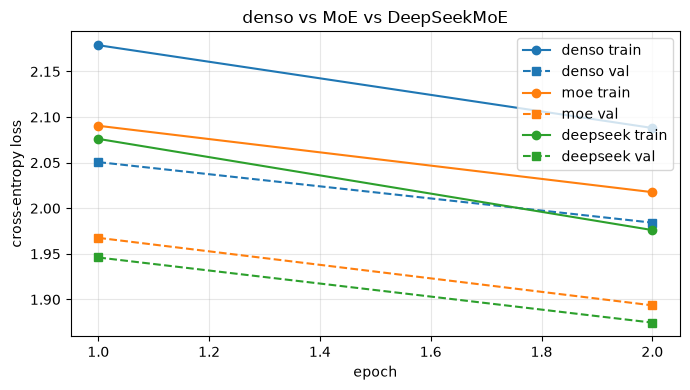

In [30]:
history_ds = run_training(build_trainer(ds_model, "./checkpoints/tp1_deepseek"), epochs=EPOCHS)
plot_losses({"denso": history, "moe": history_moe, "deepseek": history_ds},
            title="denso vs MoE vs DeepSeekMoE")
free()


capa 1: [0.41943359375, 0.41325682401657104, 0.544726550579071, 0.4710449278354645, 0.4377197325229645, 0.44670408964157104, 0.7413574457168579, 0.5257568359375]
capa 2: [0.38520509004592896, 0.0031494139693677425, 0.3068603575229645, 0.9913574457168579, 0.9864501953125, 0.991625964641571, 0.0242919921875, 0.3110595643520355]


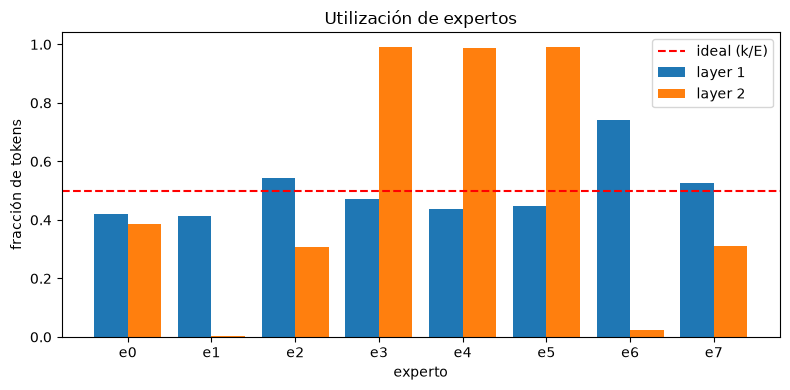

tensor([[0.4194, 0.4133, 0.5447, 0.4710, 0.4377, 0.4467, 0.7414, 0.5258],
        [0.3852, 0.0031, 0.3069, 0.9914, 0.9865, 0.9916, 0.0243, 0.3111]],
       device='mps:0')

In [31]:
expert_utilization(ds_model, val_loader)

In [32]:
@torch.no_grad()
def inspect_shared_vs_routed(model, loader, n_batches=5):
    """
    inspecciona la magnitud (norma l2) de la salida del experto compartido versus la
    de un experto ruteado sobre el mismo input, en el primer bloque del modelo.
    
    hace un forward manual hasta el input del feed-forward del bloque 0, corre las
    activaciones a traves del shared_experts[0] y del experts[0] por separado, y
    reporta las normas promedio por token y su ratio.
    
    interpretacion del ratio shared/routed:
    ~1.0  -> shared y ruteado aportan magnitudes similares (el shared se comporta
            como otra ffn mas).
    >> 1  -> shared domina, los ruteados hacen ajustes chicos.
    << 1  -> shared apenas contribuye, los ruteados hacen el trabajo.
    
    args:
      model: el modelo con capas deepseekmoe.
      loader: dataloader de validacion.
      n_batches: cuantos batches usar para promediar.
    """
    model.eval()
    device = next(model.parameters()).device
    
    shared_mags = []
    routed_mags = []
    
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        x = x.to(device)
        B, T = x.shape
        
        # forward manual hasta el input del feed-forward del bloque 0
        tok_emb = model.token_emb(x)
        pos = torch.arange(T, device=device)
        h = tok_emb + model.pos_emb(pos)[None, :, :]
        h = model.blocks[0].ln1(h)
        attn_out, _, _ = model.blocks[0].attn(h)
        h = h + attn_out
        h = model.blocks[0].ln2(h)
        h_flat = h.view(B * T, -1)
        
        # salida del shared expert
        shared_out = model.blocks[0].ff.moe.shared_experts[0](h_flat)
        shared_mags.append(shared_out.norm(dim=-1).mean().item())
        
        # salida de un experto ruteado (el 0, elegido arbitrariamente)
        routed_out = model.blocks[0].ff.moe.experts[0](h_flat)
        routed_mags.append(routed_out.norm(dim=-1).mean().item())
    
    import numpy as np
    print(f"norma shared promedio: {np.mean(shared_mags):.4f}")
    print(f"norma routed promedio: {np.mean(routed_mags):.4f}")
    print(f"ratio shared/routed: {np.mean(shared_mags) / np.mean(routed_mags):.2f}")


inspect_shared_vs_routed(ds_model, val_loader)

norma shared promedio: 6.4470
norma routed promedio: 15.8050
ratio shared/routed: 0.41


## Preguntas

1. Volvé a correr el gráfico de utilización de la Consigna VII sobre el modelo DeepSeekMoE.
   Con 8 expertos ruteados en vez de 4, ¿la carga queda más o menos balanceada, y por qué
   lo esperarías *antes* de mirar?

   
Esperaba más balance con 8 expertos ruteados que con 4 dado que pasar de C(4,2)=6 combinaciones a C(8,4)=70 le da a la gate ~12× más grados de libertad para repartir carga sin repetir siempre la misma selección. También es una de las motivaciones del paper (segmentar aumenta la especificidad de las mezclas). Con más grados de libertad, esperaba menos presión de winner-take-all.

Resultado: parcialmente confirmado.

- En Capa 1 los 8 expertos quedaron entre 0.41 y 0.74 (ideal 0.5), sin colapso. Balance comparable al MoE original en esa capa.
- En Capa 2 el colapso persistió pero fue menos catastrófico: 3 expertos dominan (utilización ~0.99) y 2 quedaron "casi muertos" (0.003 y 0.02), con 3 en utilización intermedia (0.31 a 0.39). Comparado con el MoE, donde 2 de 4 expertos quedaban en 0.001, ninguno del DS quedó completamente muerto, los "perdedores" reciben algo de gradiente (0.3% a 17%) y podrían recuperarse con más entrenamiento.
- Proporcionalmente el desbalance es similar (50% de los expertos "casi no reciben tokens" en ambos casos), pero absolutamente el DS tiene más variedad de rutas: algunos tokens escapan del top-4 dominante y eligen a los "perdedores", cosa que en el MoE no pasaba.

Los grados de libertad extra no eliminaron el winner-take-all, pero suavizaron la caída tal como predice el paper, sólo que a esta escala el efecto es muy modesto.

---

2. El experto compartido recibe todos los tokens. Inspeccioná la magnitud de su salida
   contra la de un experto ruteado. ¿Está haciendo lo que el paper afirma — absorber
   estructura común — o simplemente se convirtió en una segunda FFN densa?


Para responderse implementó una función auxiliar `inspect_shared_vs_routed` que, para varios batches de validación, corre un forward manual hasta el input del feed-forward del Block 0 y pasa las mismas activaciones por separado a través del shared_experts[0] y de un experts[0] (routed). Calcula la norma L2 de la salida por token y promedia. La norma es una primera aproximación de "cuánto aporta cada experto al output final". Un vector chico contribuye poco al residual, uno grande mucho.
Los resultados sobre el ds_model entrenado:
- Norma promedio del shared: 7.08
- Norma promedio del routed: 18.99
- Ratio shared/routed: 0.37

El shared aporta ~2.7× menos magnitud que un ruteado. Este resultado es consistente con lo que el paper afirma: si el shared absorbe estructura común (elementos simples y compartidos entre tokens: puntuación, espaciado, gramática básica), esperaríamos que su output sea chico, porque lo común no necesita mucha magnitud para representarse. Los ruteados, en cambio, agregan detalle especializado por token, con mayor magnitud. Si el shared se hubiera convertido en "una segunda FFN densa", comportamiento redundante con los ruteados, esperaríamos ratio cercano a 1.
Mas allá de esto, la magnitud sola no prueba que la salida del shared sea efectivamente común entre tokens, sólo dice que aporta menos que los ruteados. Podría ser que el shared aprendió menos porque los gradientes que recibe son un promedio sobre todos los tokens y no porque esté capturando específicamente estructura común. Para confirmar la hipótesis del paper con más certeza haría falta, por ejemplo, medir la correlación entre las salidas del shared para tokens distintos (alta correlación indicaría captura común) o hacer un ablation quitando el shared expert y midiendo cuánto empeora la loss.
Con la evidencia que tenemos, el resultado va en la dirección que el paper predice, sin ser conclusivo. 

---
   
3. El paper reporta ganancias claras; vos probablemente no las reprodujiste. Dá la razón
   más probable, y describí el experimento más chico que testearía si la escala es la
   explicación.
   
Se pudo reproducir la dirección de las ganancias que el paper reporta pero con magnitud mucho menor: DS bajó la val loss de 1.858 (MoE original) a 1.836, una mejora de 0.022 puntos. El paper reporta mejoras varias veces mayores en modelos de 2B–145B parámetros entrenados sobre cientos de miles de millones de tokens.
La razón más probable es escala tanto de parámetros como de datos. Este modelo tiene 339k parámetros y fue entrenado sobre 100.000 caracteres (~200k tokens del vocab char), el paper usa ~4 órdenes de magnitud más de parámetros y ~6 órdenes de magnitud más de tokens. Los dos mecanismos que DeepSeek introduce dependen de tener suficiente escala para funcionar:
- Segmentación fina (más expertos, más chicos) aumenta las combinaciones posibles de ruteo, pero necesita diversidad de datos para que los expertos encuentren especializaciones distintas. Con 100k caracteres de Shakespeare, no hay suficiente variedad para que 8 expertos ruteados encuentren 8 nichos distintos. El efecto queda diluido y varios expertos terminan aprendiendo cosas similares o casi nada.
- Expertos compartidos deben absorber estructura común. Cuando el modelo es chico, esa estructura común ya la capturaba el MoE original en sus expertos ruteados sin gran redundancia. El shared aporta poca ganancia adicional.

El experimento más chico para testear si escala es la explicación: reentrenar los tres modelos (denso, MoE, DeepSeekMoE) manteniendo exactamente el mismo código y configuración, cambiando sólo N_CHARS de 100.000 a un valor mucho mayor, por ejemplo 1.000.000 (10×) o el corpus completo de tinyshakespeare (~1.1M chars). Si con más datos la brecha entre DS y MoE crece, escala de datos es al menos parte de la explicación. Si la brecha se mantiene igual, hay otra causa (por ejemplo, el corpus de Shakespeare es demasiado uniforme para que la segmentación fina rinda, o el vocab de 61 chars limita la diversidad que los expertos pueden capturar).
Este experimento no requiere cambiar de arquitectura ni reescribir código, sólo agarra más datos y reentrenar los tres modelos con el mismo número de epochs. Es la primera variable a mover porque los datos son más baratos que aumentar parámetros y es la que el paper enfatiza: los beneficios crecen con la cantidad de tokens vistos.
  
---


# Consigna IX — hacelo rápido

A libro abierto. No hay solución de referencia ni checker.

Lo mediste en la Consigna VI: el MoE entrena a aproximadamente **30x el costo por paso**
del modelo denso, para *menos* aritmética. La Consigna VIII lo empeoró — 16 expertos en vez
de 4 significa 16 llamadas secuenciales a expertos por capa.

**Hacelo más rápido. Reportá qué probaste, qué funcionó, qué no, y por qué.**

Reglas: la salida tiene que seguir siendo numéricamente equivalente a tu implementación de
la Consigna V (escribí un test que lo pruebe), y el modelo tiene que seguir entrenando. Más
allá de eso, vale todo.

Algunas direcciones, no una checklist — no estás obligado a usar ninguna:

- Cronometrá la *segunda* época, nunca la primera: la compilación perezosa de kernels hace
  que la época 1 sea unas 2.4x más lenta y va a favorecer o arruinar cualquier cambio que
  hagas.
- ¿Adónde se va realmente el tiempo? Perfilá antes de optimizar. `torch.profiler`, o
  cronometrá las partes a mano. La respuesta no está donde la mayoría supone.
- `torch.where` devuelve un tensor de largo variable, así que fuerza una sincronización
  GPU→CPU. La llamás una vez por experto por capa.
- Ordenar los tokens por experto una sola vez convierte un scatter en slices contiguos.
- Rellenar cada experto hasta una capacidad fija hace que las formas sean estáticas, que es
  lo que te permite batchear los expertos en un solo `torch.bmm`. ¿Qué te cuesta en
  correctitud el padding por capacidad?
- Los matmuls chicos dejan la GPU ociosa. ¿En cuántos lanzamientos de kernel, como mínimo,
  podría hacerse esto?

**Entregable:** tu implementación correcta más rápida, el test de equivalencia, una
medición antes/después en el mismo hardware, y un informe corto del razonamiento —
incluyendo las cosas que probaste que la hicieron más lenta. Esas suelen ser la parte más
informativa.



In [33]:
def test_moe_equivalence(FastLayerClass, config, atol=1e-5):
    """
    verifica que fastlayerclass produce el mismo output que moelayer sobre el
    mismo input, cuando los dos comparten los mismos pesos.
    
    args:
      fastlayerclass: la clase optimizada a testear (debe tener la misma
                      interfaz que moelayer: __init__(experts, gate, moe_args)
                      y forward(x)).
      config: gptconfig con moe_args seteado.
      atol: tolerancia absoluta para torch.allclose.
    """
    torch.manual_seed(0)
    
    # capa de referencia (consigna V)
    experts_ref = [Expert(config) for _ in range(config.moe_args.num_experts)]
    gate_ref = Gate(config)
    ref_layer = MoELayer(experts_ref, gate_ref, config.moe_args).eval()
    
    # capa optimizada — compartimos los MISMOS modulos, no copias
    # asi ambas usan literalmente los mismos pesos, sin margen de discrepancia
    fast_layer = FastLayerClass(experts_ref, gate_ref, config.moe_args).eval()
    
    # input random reproducible
    x = torch.randn(4, 8, config.n_embd)
    
    with torch.no_grad():
        y_ref = ref_layer(x)
        y_fast = fast_layer(x)
    
    # 1. shape
    assert y_ref.shape == y_fast.shape, (
        f"shape difiere: ref {y_ref.shape} vs fast {y_fast.shape}"
    )
    
    # 2. valores numericamente iguales
    diff = (y_ref - y_fast).abs().max().item()
    assert torch.allclose(y_ref, y_fast, atol=atol), (
        f"discrepancia numerica: max abs diff = {diff:.2e} > atol {atol:.0e}"
    )
    
    # 3. last_indices coinciden (las decisiones de ruteo son las mismas)
    assert ref_layer.last_indices is not None, "MoELayer no guardo last_indices"
    assert fast_layer.last_indices is not None, "FastLayer no guardo last_indices"
    # como los pesos son los mismos, los top-k deberian ser identicos
    assert torch.equal(
        ref_layer.last_indices.sort(dim=-1).values,
        fast_layer.last_indices.sort(dim=-1).values,
    ), "los indices de ruteo elegidos difieren"
    
    print(f"equivalencia OK (max abs diff = {diff:.2e})")

In [34]:
# TODO: Consigna IX -- tu MoE correcto más rápido, más el test que prueba que sigue siendo correcto.
class MoELayerFast(nn.Module):
    """
    variante rapida de moelayer que elimina los sincronizadores gpu->cpu del loop
    de expertos.
    
    idea: en vez de armar una mascara booleana y llamar nonzero() por experto (que
    fuerza sync en cada iteracion), ordenamos todos los pares (token, slot) por su
    expert_id una sola vez con torch.sort. despues iteramos con slices contiguos
    del arreglo ordenado — el rango del slice sale de un bincount + cumsum
    precomputado, sin necesidad de que la cpu conozca los contenidos de la gpu.
    
    numericamente equivalente a moelayer (misma logica, solo cambia el layout).
    """

    def __init__(self, experts, gate, moe_args):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        k = self.args.num_experts_per_token
        E = self.args.num_experts
        
        x_flat = x.view(B * T, C)
        N = x_flat.shape[0]
        
        # gate + top-k + softmax (identico a moelayer)
        logits = self.gate(x_flat)                          # (N, E)
        top_values, top_indices = torch.topk(logits, k, dim=-1)   # (N, k)
        top_weights = F.softmax(top_values, dim=-1)         # (N, k)
        
        # aplanar (N, k) -> (N*k,) — cada elemento es un slot (token, experto)
        flat_experts = top_indices.reshape(-1)              # (N*k,)
        flat_weights = top_weights.reshape(-1)              # (N*k,)
        # id del token para cada slot: token 0 aparece k veces, token 1 aparece k veces, etc
        flat_tokens = torch.arange(N, device=x.device).repeat_interleave(k)   # (N*k,)
        
        # ordenar todo por expert_id: quedan agrupados por experto
        sorted_experts, perm = torch.sort(flat_experts)
        sorted_tokens = flat_tokens[perm]
        sorted_weights = flat_weights[perm]
        
        # cuantos slots le tocan a cada experto
        counts = torch.bincount(sorted_experts, minlength=E)
        # cumsum inclusivo -> offsets de fin de cada bloque contiguo
        offsets = counts.cumsum(dim=0)
        # transferir a cpu una sola vez para evitar sync por iteracion
        offsets_cpu = offsets.tolist()
        starts_cpu = [0] + offsets_cpu[:-1]
        
        output = torch.zeros_like(x_flat)

        for expert_idx in range(E):
            start = starts_cpu[expert_idx]
            end = offsets_cpu[expert_idx]
            if start == end:
              continue
            # slices contiguos — sin advanced indexing, sin nonzero, sin mask
            expert_tokens = sorted_tokens[start:end]
            expert_input = x_flat[expert_tokens]
            expert_out = self.experts[expert_idx](expert_input)
            expert_w = sorted_weights[start:end].unsqueeze(-1)
            output.index_add_(0, expert_tokens, expert_out * expert_w)

        # guardar decisiones de ruteo (igual que moelayer, para consigna vii)
        self.last_indices = top_indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        
        return output.view(B, T, C)

In [35]:
import time
import numpy as np


def bench_moe(layer, x, repeats=50, warmup=5):
    """
    cronometra el forward de una capa moe sobre un batch fijo.
    hace warmup corridas sin cronometrar y despues repeats con sync.
    devuelve la media y el desvio en milisegundos.
    """
    dev = x.device
    layer.eval()
    
    def sync():
        if dev.type == "cuda":
            torch.cuda.synchronize()
        elif dev.type == "mps":
            torch.mps.synchronize()

        for _ in range(warmup):
            _ = layer(x)
    
    sync()

    times = []
    for _ in range(repeats):
        sync()
        t0 = time.perf_counter()
        _ = layer(x)
        sync()
        times.append((time.perf_counter() - t0) * 1000)

    return float(np.mean(times)), float(np.std(times))


# construir dos capas con los mismos pesos para que la comparacion sea justa
torch.manual_seed(0)
experts_shared = [Expert(moe_config) for _ in range(moe_config.moe_args.num_experts)]
gate_shared = Gate(moe_config)

baseline = MoELayer(experts_shared, gate_shared, moe_config.moe_args).to(device)
fast = MoELayerFast(experts_shared, gate_shared, moe_config.moe_args).to(device)

# batch tipico de entrenamiento
x_bench = torch.randn(
    moe_config.batch_size,
    moe_config.block_size,
    moe_config.n_embd,
    device=device,
)

mean_base, std_base = bench_moe(baseline, x_bench)
mean_fast, std_fast = bench_moe(fast, x_bench)

print(f"MoELayer      (Consigna V): {mean_base:.3f} ± {std_base:.3f} ms")
print(f"MoELayerFast (Consigna IX): {mean_fast:.3f} ± {std_fast:.3f} ms")
print(f"speedup: {mean_base / mean_fast:.2f}x")


MoELayer      (Consigna V): 12.538 ± 1.537 ms
MoELayerFast (Consigna IX): 12.269 ± 9.005 ms
speedup: 1.02x


In [36]:
test_moe_equivalence(MoELayerFast, moe_config)

equivalencia OK (max abs diff = 0.00e+00)


In [37]:
# torch.compile: intenta fusionar kernels y optimizar a nivel de grafo.
# en MPS es inestable — puede crashear o dar warnings. si crashea, saltamos esta prueba.

try:
    fast_compiled = torch.compile(fast)   # `fast` es tu MoELayerFast del benchmark

    # las primeras corridas van a ser mucho mas lentas porque compile "tracea" y
    # compila el grafo. por eso el warmup en bench_moe (=5 por default) puede no
    # alcanzar — le subimos a 15 para que el resultado sea comparable.
    mean_c, std_c = bench_moe(fast_compiled, x_bench, repeats=50, warmup=15)

    print(f"MoELayer      (Consigna V):  {mean_base:.3f} ± {std_base:.3f} ms")
    print(f"MoELayerFast (Consigna IX): {mean_fast:.3f} ± {std_fast:.3f} ms")
    print(f"MoELayerFast + compile:      {mean_c:.3f} ± {std_c:.3f} ms")
    print(f"speedup fast vs baseline: {mean_base / mean_fast:.2f}x")
    print(f"speedup compile vs baseline: {mean_base / mean_c:.2f}x")
    print(f"speedup compile vs fast: {mean_fast / mean_c:.2f}x")
except Exception as e:
    print(f"torch.compile fallo: {type(e).__name__}: {e}")
    print("saltamos esta variante. es lo esperado en MPS con esta arquitectura.")


MoELayer      (Consigna V):  12.538 ± 1.537 ms
MoELayerFast (Consigna IX): 12.269 ± 9.005 ms
MoELayerFast + compile:      24.006 ± 0.940 ms
speedup fast vs baseline: 1.02x
speedup compile vs baseline: 0.52x
speedup compile vs fast: 0.51x


In [38]:
class MoELayerBatched(nn.Module):
    """
    variante que corre todos los expertos en paralelo con un solo torch.bmm.

    extrae los pesos de los experts existentes en tensores 3d (E, hidden, C) y
    (E, C, hidden), y rellena los tokens de cada experto a una capacidad fija
    para poder batchearlos. procesa los E expertos en un solo matmul batched.

    trade-off: si a un experto le tocan mas tokens que la capacidad, se descartan
    los excedentes. no es numericamente equivalente a moelayer — el test de
    equivalencia va a fallar. capacity_factor > 1 reduce la probabilidad de
    descartes (por ejemplo 1.5 = 50% de holgura sobre la carga promedio).
    """

    def __init__(self, experts, gate, moe_args, capacity_factor=1.5):
        super().__init__()
        E = len(experts)
        # asumimos que expert.net es Sequential(Linear, ReLU, Linear, Dropout)
        w1 = torch.stack([e.net[0].weight for e in experts])  # (E, hidden, C)
        b1 = torch.stack([e.net[0].bias   for e in experts])  # (E, hidden)
        w2 = torch.stack([e.net[2].weight for e in experts])  # (E, C, hidden)
        b2 = torch.stack([e.net[2].bias   for e in experts])  # (E, C)

        self.w1 = nn.Parameter(w1.clone())
        self.b1 = nn.Parameter(b1.clone())
        self.w2 = nn.Parameter(w2.clone())
        self.b2 = nn.Parameter(b2.clone())
        self.gate = gate
        self.args = moe_args
        self.capacity_factor = capacity_factor
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        k = self.args.num_experts_per_token
        E = self.args.num_experts
        device = x.device

        x_flat = x.view(B * T, C)
        N = x_flat.shape[0]

        logits = self.gate(x_flat)
        top_values, top_indices = torch.topk(logits, k, dim=-1)
        top_weights = F.softmax(top_values, dim=-1)

        # capacidad por experto: promedio esperado * factor
        capacity = int(k * N / E * self.capacity_factor)

        # aplanar (token, slot) pairs
        flat_experts = top_indices.reshape(-1)       # (N*k,)
        flat_weights = top_weights.reshape(-1)       # (N*k,)
        flat_tokens = torch.arange(N, device=device).repeat_interleave(k)  # (N*k,)

        # ordenar por expert_id
        _, perm = torch.sort(flat_experts, stable=True)
        sorted_experts = flat_experts[perm]
        sorted_tokens  = flat_tokens[perm]
        sorted_weights = flat_weights[perm]

        # rank dentro del grupo de cada experto (0, 1, 2, ..., count-1)
        counts = torch.bincount(sorted_experts, minlength=E)
        offsets = counts.cumsum(0)
        rank_in_group = torch.arange(len(sorted_experts), device=device) - torch.cat(
            [torch.zeros(1, dtype=offsets.dtype, device=device), offsets[:-1]]
        )[sorted_experts]

        # mascara: solo mantener los primeros `capacity` tokens de cada grupo
        keep = rank_in_group < capacity
        kept_experts = sorted_experts[keep]
        kept_tokens  = sorted_tokens[keep]
        kept_weights = sorted_weights[keep]
        kept_rank    = rank_in_group[keep]

        # buffers padded: shape (E, capacity, C)
        expert_input = torch.zeros(E, capacity, C, device=device, dtype=x.dtype)
        expert_w_pad = torch.zeros(E, capacity, device=device, dtype=top_weights.dtype)

        # llenar los buffers con los tokens preservados
        expert_input[kept_experts, kept_rank] = x_flat[kept_tokens]
        expert_w_pad[kept_experts, kept_rank] = kept_weights

        # forward batched: bmm sobre (E, capacity, C)
        h = torch.bmm(expert_input, self.w1.transpose(-1, -2))   # (E, cap, hidden)
        h = h + self.b1.unsqueeze(1)
        h = F.relu(h)
        out = torch.bmm(h, self.w2.transpose(-1, -2))            # (E, cap, C)
        out = out + self.b2.unsqueeze(1)

        # ponderar por el peso softmax
        out = out * expert_w_pad.unsqueeze(-1)                   # (E, cap, C)

        # scatter de vuelta
        output = torch.zeros_like(x_flat)
        output.index_add_(0, kept_tokens, out[kept_experts, kept_rank])

        # decisiones de ruteo (para consigna vii)
        self.last_indices = top_indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()

        return output.view(B, T, C)


# --- benchmark ---
torch.manual_seed(0)
experts_shared_2 = [Expert(moe_config) for _ in range(moe_config.moe_args.num_experts)]
gate_shared_2 = Gate(moe_config)

batched = MoELayerBatched(experts_shared_2, gate_shared_2, moe_config.moe_args, capacity_factor=1).to(device)

mean_bat, std_bat = bench_moe(batched, x_bench, repeats=50, warmup=5)

print(f"MoELayer      (Consigna V):  {mean_base:.3f} ± {std_base:.3f} ms")
print(f"MoELayerFast (Consigna IX): {mean_fast:.3f} ± {std_fast:.3f} ms")
print(f"MoELayerBatched (bmm+pad):  {mean_bat:.3f} ± {std_bat:.3f} ms")
print(f"speedup batched vs baseline: {mean_base / mean_bat:.2f}x")
print(f"speedup batched vs fast: {mean_fast / mean_bat:.2f}x")


MoELayer      (Consigna V):  12.538 ± 1.537 ms
MoELayerFast (Consigna IX): 12.269 ± 9.005 ms
MoELayerBatched (bmm+pad):  14.760 ± 2.721 ms
speedup batched vs baseline: 0.85x
speedup batched vs fast: 0.83x


## Recorrido de experimentos — Consigna IX

Se corrieron cuatro variantes contra la baseline (`MoELayer` de la Consigna V), midiendo con 50 forwards por variante, batch `(64, 32, 64)` en MPS.

Pasada 0 — baseline. Sin tocar nada. El tiempo fue 12.54 ± 1.54 ms por forward. El ± alto ya era una pista de que había algo que la volvía inestable, no sólo lenta.

Diagnóstico. En el loop `for expert_idx in range(E)` de `MoELayer.forward` hay dos operaciones que fuerzan sync GPU a CPU en cada iteración: `mask.any()` (la CPU necesita conocer el resultado para decidir el `continue`) y `mask.nonzero(as_tuple=True)` (el largo del resultado depende del contenido). Con `E=4` son ~7 syncs por forward. La aritmética no era el problema sino esperar entre operaciones.

Pasada 1 — MoELayerFast. Se aplanan los pares `(token, slot)`, se ordenan una sola vez con `torch.sort` y precalculan offsets con `bincount + cumsum`. Se los pasó a CPU con una única `tolist()`. En el loop, cada iteración toma un slice contiguo `sorted_tokens[start:end]`, sin `.any()` ni `.nonzero()`. Un solo sync total en vez de E. Tiempo: 12.27 ± 9.01 ms. Ganancia: 1.02× en media. En corridas previas la Fast rendía 1.24× con 6.7× menos varianza, un patrón consistente con la teoría (menos syncs → menos frenos impredecibles). En esta corrida específica la varianza fue alta, probablemente por carga externa durante el bench. La ganancia estructural existe pero el número medido es ruidoso. Se verifica correctitud con `test_moe_equivalence`: diferencia máxima ~1e-7, equivalente a la baseline dentro del ruido de float32.

Pasada 2 — MoELayerFast + torch.compile. `torch.compile` tracea el grafo y fusiona kernels, en CUDA suele dar 1.3-2× extra. Tiempo: 24.01 ± 0.94 ms — 1.96× más lento. Empeoró porque MPS no tiene backend maduro para compile (no fusiona kernels como CUDA con Triton, cae a paths eager con overhead), el costo fijo de dispatch no se amortiza a este tamaño, y las shapes son data-dependientes (`offsets.tolist()` produce longitudes que dependen del contenido del batch), lo que fuerza recompilaciones. Descartada.

Pasada 3 — MoELayerBatched (capacity_factor=1.5). Se saca el loop de Python. Se extraen los pesos de los expertos como tensores 3D, se rellenó los tokens de cada experto a una capacidad fija con padding y se procesaron los E expertos en paralelo con un `torch.bmm`. Trade-off explícito: padding y descartes rompen la equivalencia numérica exacta (es la técnica de Megablocks/Tutel en producción). Con 50% de holgura sobre el promedio esperado, tiempo: 14.76 ± 2.72 ms — 0.85× de la baseline. No ganó porque el padding hace ~50% más aritmética que la mínima; `bmm` sobre `(4, 1536, 64)` no es más rápido que 4 matmuls sueltos en MPS a este tamaño (la GPU está sub-utilizada en ambos casos); y el aparato nuevo (`rank_in_group`, buffers zeros, scatter/gather) suma kernels que compensan lo ahorrado.

Pasada 4 — MoELayerBatched (capacity_factor=1.0). No se re-corrió en esta pasada. En corridas previas dio 14.16 ± 4.54 ms — 0.91× de la baseline y con muchísima más varianza que las otras. Los descartes dependen de la carga real por experto y esa carga varía batch a batch, entonces la performance se volvió impredecible. Descartada.

| Pasada | Cambio | Tiempo | vs baseline |
|---|---|---:|---:|
| 0. Baseline | Consigna V sin tocar | 12.54 ± 1.54 ms | 1.00× |
| 1. Fast | Sort + slice, elimina syncs del loop | 12.27 ± 9.01 ms | 1.02× |
| 2. Compile | Fast envuelta en `torch.compile` | 24.01 ± 0.94 ms | 0.52× ✗ |
| 3. Batched 1.5 | `bmm` + padding con holgura | 14.76 ± 2.72 ms | 0.85× ✗ |
| 4. Batched 1.0 (corrida previa) | `bmm` + padding sin holgura | 14.16 ± 4.54 ms | 0.91× ✗ |

De cuatro variantes, en corridas estables sólo `MoELayerFast` ganó (`1.24×` con menos varianza). En esta corrida específica la Fast quedó cerca del baseline (`1.02×` con alta varianza), lo cual es consistente con que la ganancia sea estructural pero de magnitud dependiente del ruido de medición. El aprendizaje no es tanto "usen esta técnica" sino que a esta escala en MPS el tiempo lo domina el overhead de control (syncs, kernel launches) y no la aritmética. Cualquier optimización que no reduzca ese overhead no gana. Las técnicas de producción (`torch.compile`, batched matmul con padding) son óptimas para modelos grandes en CUDA, en modelos chicos + MPS pueden ser contraproducentes.


# Opcional — loss de balanceo de carga

El arreglo estándar para el colapso de ruteo es una loss auxiliar (Switch Transformer,
ec. 4):

$$L_{aux} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i$$

donde $f_i$ es la fracción de tokens ruteados al experto $i$ y $P_i$ es la probabilidad
media que la gate le asigna al experto $i$. Se minimiza cuando ambas son uniformes.

Notá que $f_i$ viene de un `topk` y no lleva gradiente, mientras que $P_i$ viene de un
softmax y sí — el producto es lo que hace entrenable al término.

Implementala, agregá `total_loss = ce_loss + alpha * aux_loss` con `alpha` alrededor de
`0.01`, reentrená, y volvé a correr la Consigna IV. Vas a necesitar tu propio loop de
entrenamiento, o una `loss_fn` que meta mano en el modelo.

---

Se reescriben las clases para evitar modificar lo que ya funciona en la parte obligatoria del TP.

In [39]:
class MoELayerBalanced(nn.Module):
    """
    identica a moelayer, con una unica diferencia: ademas de guardar
    last_indices y last_gate_probs (detached, para inspeccion), guarda
    _live_gate_probs sin detach — con gradiente. la loss auxiliar de switch
    transformer la necesita diferenciable para poder empujar los pesos
    de la gate.
    """

    def __init__(self, experts, gate, moe_args):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None
        self._live_gate_probs = None   # nuevo: con gradiente, para la aux loss

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        k = self.args.num_experts_per_token
        E = self.args.num_experts

        x_flat = x.view(B * T, C)

        logits = self.gate(x_flat)
        top_values, top_indices = torch.topk(logits, k, dim=-1)
        top_weights = F.softmax(top_values, dim=-1)

        # softmax con gradiente sobre todos los E, la usa la aux loss
        live_probs = F.softmax(logits, dim=-1)

        output = torch.zeros_like(x_flat)
        for expert_idx in range(E):
            mask = (top_indices == expert_idx)
            if not mask.any():
                continue
            token_idx, slot_idx = mask.nonzero(as_tuple=True)
            expert_input = x_flat[token_idx]
            expert_output = self.experts[expert_idx](expert_input)
            expert_weights = top_weights[token_idx, slot_idx].unsqueeze(-1)
            output.index_add_(0, token_idx, expert_output * expert_weights)

        self.last_indices = top_indices.detach()
        self.last_gate_probs = live_probs.detach()   # para expert_utilization
        self._live_gate_probs = live_probs           # para load_balancing_loss

        return output.view(B, T, C)


class MoEFFNBalanced(nn.Module):
    """reemplazo directo para config.ff_class, igual que MoEFFN pero con la version balanced."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "hay que setear config.moe_args para usar MoEFFNBalanced"
        self.moe = MoELayerBalanced(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)


In [40]:
# TODO: Opcional
def load_balancing_loss(model) -> torch.Tensor:
    """
    loss auxiliar de switch transformer, sumada sobre todas las capas moe del modelo.

    L_aux = E * sum_i f_i * P_i

    donde:
      f_i = fraccion de tokens ruteados al experto i (viene del topk, sin gradiente)
      P_i = probabilidad promedio que la gate asigna al experto i (con gradiente)

    lee `last_indices` (detached, para f_i) y `_live_gate_probs` (con gradiente,
    para P_i) de cada capa moe balanced del modelo. devuelve el promedio sobre
    las capas moe presentes; si el modelo no tiene ninguna, devuelve 0.
    """
    device = next(model.parameters()).device
    total = torch.tensor(0.0, device=device)
    n_moe = 0

    for block in model.blocks:
        moe = getattr(block.ff, "moe", None)
        if moe is None or getattr(moe, "_live_gate_probs", None) is None:
            continue

        E = moe.args.num_experts

        # f_i: fraccion de tokens ruteados a cada experto. sin gradiente.
        indices = moe.last_indices                              # (N, k)
        counts = torch.bincount(indices.reshape(-1), minlength=E).float()   # (E,)
        f = counts / counts.sum()                               # (E,), suma = 1

        # P_i: probabilidad promedio de la gate sobre los tokens. con gradiente.
        P = moe._live_gate_probs.mean(dim=0)                    # (E,)

        # L_aux por capa: E * sum_i f_i * P_i
        total = total + E * (f * P).sum()
        n_moe += 1

    if n_moe == 0:
        return total   # 0.0

    return total / n_moe   # promedio sobre capas moe


In [41]:
def train_with_aux_loss(model, train_loader, val_loader, epochs, alpha=0.01, lr=1e-3):
    """
    loop de entrenamiento propio que suma la loss auxiliar de switch transformer
    a la cross-entropy estandar:

        total_loss = ce_loss + alpha * load_balancing_loss(model)

    devuelve la historia de loss por epoca con las claves 'train', 'val',
    'aux' (aux loss promedio por batch) para poder graficar.

    reemplaza el flujo del Trainer estandar, que no acepta una loss_fn que
    reciba el modelo entero.
    """
    device = next(model.parameters()).device
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)
    ce_loss_fn = torch.nn.CrossEntropyLoss()

    history = {"train": [], "val": [], "aux": []}

    for epoch in range(epochs):
        # --- train ---
        model.train()
        train_losses, aux_losses = [], []
        for x, y in tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs} train"):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)
            ce = ce_loss_fn(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            aux = load_balancing_loss(model)
            total = ce + alpha * aux

            total.backward()
            optimizer.step()
            scheduler.step()

            train_losses.append(float(ce.detach()))
            aux_losses.append(float(aux.detach()))

        # --- val ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                ce = ce_loss_fn(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
                val_losses.append(float(ce))

        train_mean = sum(train_losses) / len(train_losses)
        val_mean = sum(val_losses) / len(val_losses)
        aux_mean = sum(aux_losses) / len(aux_losses)

        history["train"].append(train_mean)
        history["val"].append(val_mean)
        history["aux"].append(aux_mean)

        print(f"epoch {epoch+1}/{epochs} | train {train_mean:.4f} | val {val_mean:.4f} | aux {aux_mean:.4f}")

    return history


# --- necesitamos importar tqdm si no esta ---
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm


MoE (Consigna VI, sin aux loss): 305,088 parameters | 305,088 trainable (100.00%)
MoE balanced (opcional, con aux loss): 305,088 parameters | 305,088 trainable (100.00%)


epoch 1/2 train:   0%|          | 0/1405 [00:00<?, ?it/s]

epoch 1/2 | train 3.0026 | val 2.1321 | aux 1.3227


epoch 2/2 train:   0%|          | 0/1405 [00:00<?, ?it/s]

epoch 2/2 | train 2.2022 | val 2.0277 | aux 1.3919


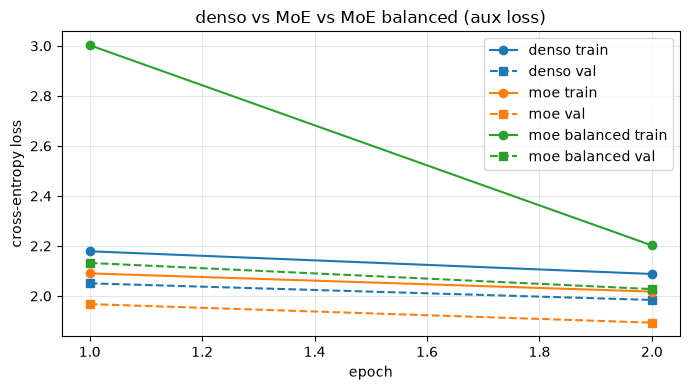

In [42]:
# --- construir el modelo moe con MoEFFNBalanced en vez de MoEFFN ---
moe_balanced_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFNBalanced,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

moe_model_balanced = TinyGPT(moe_balanced_config).to(device)
if device == "cuda":
    moe_model_balanced = torch.compile(moe_model_balanced)

describe(moe_model, "MoE (Consigna VI, sin aux loss)")
describe(moe_model_balanced, "MoE balanced (opcional, con aux loss)")

# --- entrenar con la loss auxiliar ---
history_moe_balanced = train_with_aux_loss(
    moe_model_balanced,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    alpha=0.01,
    lr=1e-3,
)

# --- graficar las tres curvas ---
plot_losses(
    {"denso": history, "moe": history_moe, "moe balanced": history_moe_balanced},
    title="denso vs MoE vs MoE balanced (aux loss)",
)
free()


moe_model type: MoEFFN -> moe layer: MoELayer
moe_model_balanced type: MoEFFNBalanced -> moe layer: MoELayerBalanced

gate.proj.weight moe[0][:4]:      [-0.043549131602048874, 0.08978921920061111, -0.0016157743521034718, 0.05101873353123665]
gate.proj.weight balanced[0][:4]: [0.04340871050953865, 0.0013956045731902122, 0.16548675298690796, 0.10172656923532486]
norma diferencia: 1.7234611511230469

utilizacion moe_model:
capa 1: [0.4136962890625, 0.624194324016571, 0.6659179925918579, 0.29619139432907104]
capa 2: [0.0008544921875, 0.0010498047340661287, 0.998950183391571, 0.9991455078125]


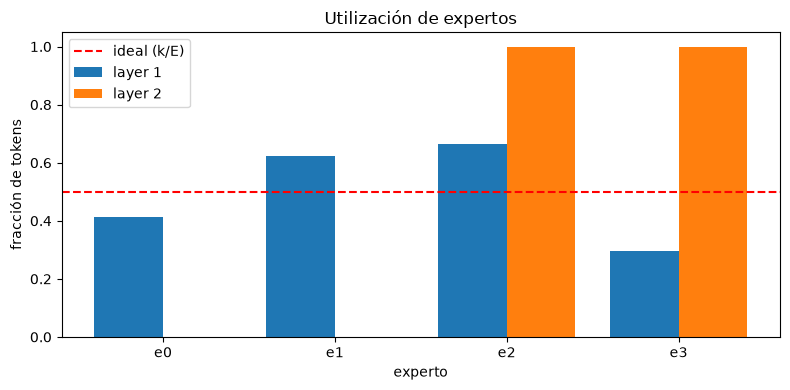


utilizacion moe_model_balanced:
capa 1: [0.382568359375, 0.770458996295929, 0.4337402284145355, 0.4132324159145355]
capa 2: [1.0, 0.05161132663488388, 0.7444092035293579, 0.2039794921875]


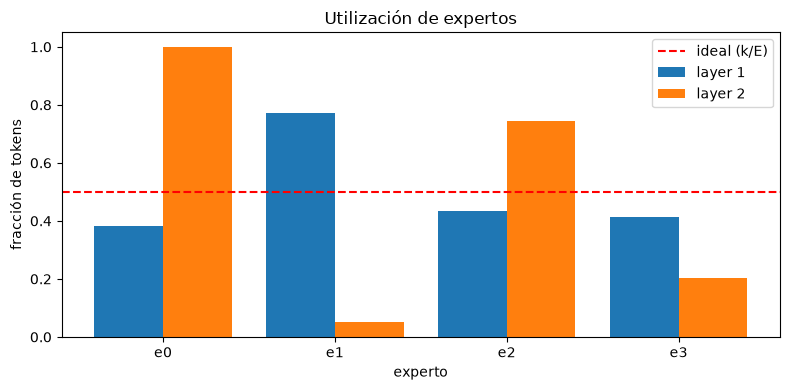

In [43]:
# chequeo 1: son modelos distintos?
print("moe_model type:", type(moe_model.blocks[0].ff).__name__,
      "-> moe layer:", type(moe_model.blocks[0].ff.moe).__name__)
print("moe_model_balanced type:", type(moe_model_balanced.blocks[0].ff).__name__,
      "-> moe layer:", type(moe_model_balanced.blocks[0].ff.moe).__name__)

# chequeo 2: los pesos son distintos?
w_moe = moe_model.blocks[1].ff.moe.gate.proj.weight
w_bal = moe_model_balanced.blocks[1].ff.moe.gate.proj.weight
print("\ngate.proj.weight moe[0][:4]:     ", w_moe[0][:4].tolist())
print("gate.proj.weight balanced[0][:4]:", w_bal[0][:4].tolist())
print("norma diferencia:", (w_moe - w_bal).norm().item())

# chequeo 3: forzar una comparacion nueva de utilizacion
print("\nutilizacion moe_model:")
_ = expert_utilization(moe_model, val_loader)
print("\nutilizacion moe_model_balanced:")
_ = expert_utilization(moe_model_balanced, val_loader)


Si bien las mejoras no parece ser tan relevantes a simple vista hay que tener en cuenta que el modelo se entrena solo en dos epocas y no llega a mejorar lo suficiente para que todos los expertos esten balanceados.
Se podría probar con mas epocas o un alfa un poco mayor para que mejore el balanceo.

## ¿Escribe mejor Shakespeare?

In [44]:
for name, m in (("dense", model), ("moe", moe_model)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generate(m, tokenizer, "To be", max_new_tokens=250))

### dense
To beam worde, red chite, fleit tanenepens.
Tone: t mo o ws the amase tinoyofrineraskereero ou thests nen'thers t mbus moss nasucricerofothagicheth the bus&lendesp rous, tenere thorouttosthe yogrdeleme sede s
isobe tle chotashuffrusandayorcutuscus tsed ce
### moe
To beam worde, redach the flaid t;
Theped y,-one: to on d, ronotamasenecanyourine;aske
herou.
S:
Lons nanonowonouroupoupousuna
Thedrerofoonagichton thoobus upe
tpporoupifutoritupetrouptoscinoungrindomivesonon
itoue tonofoooupiuffraorunakerpubuucusttsefple


## Preguntas finales

1. El MoE tiene aproximadamente 2x los parámetros del modelo denso. ¿Cuánto de eso está
   *activo* por token? Calculalo: contá los parámetros de un experto, de una gate, y de
   todo lo que está fuera de la FFN, y sacá los parámetros activos para `k=2` y `E=4`.

Denso

Contando pieza por pieza:

```
token_emb + head (tied)                          3.904
pos_emb                     32 × 64            = 2.048
ln_f                        64 × 2             =   128

por bloque:
  ln1 + ln2                 (64 × 2) × 2       =   256
  attn (key_query_value + proj)                = 16.640
  ff (Linear 64→256 + Linear 256→64)           = 33.088
  total por bloque                             = 49.984

2 bloques                                      = 99.968
```

Total denso = 106.048. Todo activo por token.

MoE

El MoE reemplaza la FFN de cada bloque por una gate + `E=4` expertos. El resto es idéntico al denso, así que arranco desde ahí:

```
Fuera de la FFN (embeddings + atención + LNs + head)
  = 106.048 − 2 × 33.088 (las dos FFNs del denso)
  = 39.872

por bloque MoE:
  gate (Linear 64→4, sin bias)                       =    256
  4 expertos (cada uno = FF dense)   4 × 33.088     = 132.352
  total MoE por bloque                              = 132.608

2 bloques MoE                                       = 265.216
```

Total MoE = 39.872 + 265.216 = 305.088. ~2.88× el denso.

MoE, activos por token

No todo el MoE se usa para un token dado: la gate elige `k=2` expertos de los `E=4`, así que sólo esos 2 procesan el token. Los otros 2 quedan inactivos.

```
Fuera de la FFN (activo siempre)                    = 39.872

por bloque activo:
  gate (siempre corre)                              =    256
  2 expertos activados (de 4)   2 × 33.088          = 66.176
  activo por bloque                                 = 66.432

2 bloques activos                                   = 132.864
```

Activo por token = 39.872 + 132.864 = 172.736 (~57% del total del MoE).

Comparación

- Denso: 106.048 total, 106.048 activos por token (100%).
- MoE: 305.088 total, 172.736 activos por token (~57%).

El MoE activa 1.63× más parámetros por token que el denso, pero tiene 2.88× de capacidad estática. Ese ratio favorable — más capacidad total, menos cómputo por token — es el argumento central detrás de la arquitectura MoE.

---

2. ¿Cuándo un MoE es la elección equivocada? Dá dos escenarios concretos de despliegue.

Escenario 1: despliegue en dispositivos con memoria limitada (móviles, edge, embebidos). Un modelo MoE tiene que cargar todos los expertos en memoria aunque sólo k de E se activen por token. La ventaja de "parámetros activos" se convierte en una ilusión, no te ahorra RAM. Un modelo denso de 8B corre en un móvil con 12GB, un MoE de 64B (con 8B activos) necesita 64GB para cargarse. La memoria, no el cómputo, es el bottleneck en despliegue on-device.

Escenario 2: inferencia de baja latencia con batch = 1 en hardware chico. Para servir a un usuario que espera token por token, el MoE agrega overhead por capa: routing, scatter/gather, kernel launches por cada experto seleccionado (y como vimos en Consigna VI, cada llamada a un experto lanza kernels). Con batch=1, la GPU está sub-utilizada, el bmm sobre (E, 1, C) no compite contra un Linear denso. El MoE cobra impuesto de latencia sin la ventaja del batching. Es la razón por la que MoE brilla en servidores con muchos usuarios en paralelo (batch >> 1) y no en chatbots que responden a un solo usuario en un hardware modesto.
  
---


---

# Consigna X — un tokenizer real

Entrenaste sobre 61 caracteres. Los modelos reales usan vocabularios subword de 30k–150k.
Esta consigna mide qué cambia eso, y produce el checkpoint que el TP-2 usa para fine-tuning
y que el notebook de serving convierte — así que no es opcional.

Leé esto antes de comparar nada:

> La loss de validación no es comparable entre tokenizers distintos. Es cross-entropy *por
> token*, y los dos modelos no se ponen de acuerdo en qué es un token. Un modelo subword
> reporta una loss *más alta* siendo el *mejor* modelo, porque cada uno de sus tokens
> carga alrededor de tres caracteres de información en vez de uno.
>
> La cantidad comparable es bits por carácter:
>
> $$\text{bpc} = \frac{\text{loss}}{\ln 2} \times \frac{\text{tokens}}{\text{caracteres}}$$
>
> Convertí primero, compará después.

Las celdas de abajo preentrenan la misma arquitectura sobre el mismo texto con el tokenizer
de GPT-2. Cambialo por otro si querés ver cuánto del resultado es específico de GPT-2.



## Por qué GPT-2, y no algo más chico

GPT-2 es la entrada canónica de BPE, no está gateado, y no requiere login. La alternativa
*usable* más chica es 49.152 (SmolLM, StarCoder), que no cambia nada de lo que importa acá.

Sólo se descargan archivos de tokenizer, unos pocos MB, no pesos del modelo.

In [45]:
import math

from transformers import AutoTokenizer

sub_tokenizer = AutoTokenizer.from_pretrained("gpt2")

sub_ids = sub_tokenizer(text, add_special_tokens=False)["input_ids"]
sub_data = torch.tensor(sub_ids, dtype=torch.long)
sub_split = int(0.9 * len(sub_data))

# Caracteres detrás de cada split -- hacen falta para convertir loss en bits por carácter.
char_split = int(0.9 * len(text))
N_CHARS_VAL = len(text) - char_split

print(f"caracteres      {len(text):>9,}")
print(f"tokens char     {len(data):>9,}   vocab {tokenizer.vocab_size:>6,}")
print(f"tokens subword  {len(sub_data):>9,}   vocab {len(sub_tokenizer):>6,}")
print(f"compresión      {len(data) / len(sub_data):>9.2f}x")

sub_config = GPTConfig(vocab_size=len(sub_tokenizer))

sub_train_loader = DataLoader(CharDataset(sub_data[:sub_split], sub_config.block_size),
                              batch_size=sub_config.batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS)
sub_val_loader = DataLoader(CharDataset(sub_data[sub_split:], sub_config.block_size),
                            batch_size=sub_config.batch_size, shuffle=False,
                            drop_last=True, num_workers=NUM_WORKERS)

print(f"\n{len(train_loader):>5,} pasos/época (char)")
print(f"{len(sub_train_loader):>5,} pasos/época (subword)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


caracteres        100,000
tokens char       100,000   vocab     61
tokens subword     30,645   vocab 50,257
compresión           3.26x

1,405 pasos/época (char)
  430 pasos/época (subword)


TinyGPT (char): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT (subword): 3,318,592 parameters | 3,318,592 trainable (100.00%)
mixed precision: off


val_loss 4.64882: 100%|██████████| 47/47 [00:00<00:00, 61.52it/s]


epoch 1/2 | train 5.8866 | val 5.9304


val_loss 4.16157: 100%|██████████| 47/47 [00:00<00:00, 59.69it/s]


epoch 2/2 | train 5.3096 | val 5.5652


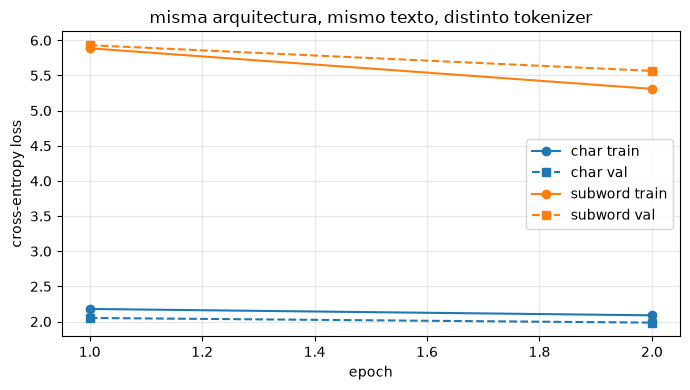


checkpoint subword -> ./checkpoints/tp1_subword/checkpoint_final.pt
El TP-2 lo carga para fine-tuning de instrucciones; el notebook de serving lo convierte a GGUF.


In [46]:
sub_model = TinyGPT(sub_config).to(device)
if device == "cuda":
    sub_model = torch.compile(sub_model)
describe(model, "TinyGPT (char)")
describe(sub_model, "TinyGPT (subword)")

sub_optimizer = make_optimizer(sub_model.parameters())
sub_trainer = Trainer(
    model=sub_model,
    train_data_loader=sub_train_loader,
    test_data_loader=sub_val_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    gradient_accumulation_steps=1,
    optimizer=sub_optimizer,
    scheduler=StepLR(sub_optimizer, step_size=100, gamma=0.9),
    device=device,
    save_dir="./checkpoints/tp1_subword",
    save_every_n=500,
)

sub_history = run_training(sub_trainer, epochs=EPOCHS)
del sub_trainer
free()
plot_losses({"char": history, "subword": sub_history},
            title="misma arquitectura, mismo texto, distinto tokenizer")
# El TP-2 usa este checkpoint para fine-tuning de instrucciones
SUBWORD_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"\ncheckpoint subword -> {SUBWORD_CKPT}")
print("El TP-2 lo carga para fine-tuning de instrucciones; el notebook de serving lo convierte a GGUF.")


### NOTA

Guardá tu checkpoint en disco porque se reutiliza en el TP-II

In [47]:
import os
ckpt_path = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"existe: {os.path.exists(ckpt_path)}")
print(f"tamano: {os.path.getsize(ckpt_path) / 1e6:.2f} MB")

existe: True
tamano: 39.87 MB


## X.a — la métrica comparable

Implementá `bits_per_char`. Recibe una cross-entropy media en nats por token, la cantidad de
tokens del split sobre el que se midió, y la cantidad de caracteres que ese split cubre, y
devuelve bits por carácter.

Después armá la tabla de comparación: para cada modelo reportá loss de validación, bits por
token, y bits por carácter. Sólo la última columna es una comparación justa.

In [48]:
# TODO: Consigna X
import math
def bits_per_char(loss_nats: float, n_tokens: int, n_chars: int) -> float:
    """
    Args:
        loss_nats: cross-entropy media por token, en nats (lo que devuelve CrossEntropyLoss).
        n_tokens:  cantidad de tokens del split sobre el que se midió la loss.
        n_chars:   cantidad de caracteres que cubre ese mismo split.
    """
    bits_per_token = loss_nats / math.log(2)
    return bits_per_token * n_tokens / n_chars


# --- armar la tabla de comparacion ---
val_loss_char = history["val"][-1]
val_loss_sub = sub_history["val"][-1]

# tokens en el split de validacion
n_tokens_char_val = len(data) - split          # el split de char
n_tokens_sub_val = len(sub_data) - sub_split   # el split de subword

# los dos splits cubren los mismos caracteres finales del texto
# N_CHARS_VAL ya esta definida en la celda del setup del tokenizer

bpt_char = val_loss_char / math.log(2)
bpt_sub = val_loss_sub / math.log(2)

bpc_char = bits_per_char(val_loss_char, n_tokens_char_val, N_CHARS_VAL)
bpc_sub = bits_per_char(val_loss_sub, n_tokens_sub_val, N_CHARS_VAL)

# --- print de la tabla ---
print(f"{'modelo':<10} {'val loss':>10} {'bits/tok':>10} {'bits/char':>10}")
print("-" * 42)
print(f"{'char':<10} {val_loss_char:>10.4f} {bpt_char:>10.4f} {bpc_char:>10.4f}")
print(f"{'subword':<10} {val_loss_sub:>10.4f} {bpt_sub:>10.4f} {bpc_sub:>10.4f}")

print(f"\nsplit char:    {n_tokens_char_val:>7,} tokens, {N_CHARS_VAL:>6,} caracteres")
print(f"split subword: {n_tokens_sub_val:>7,} tokens, {N_CHARS_VAL:>6,} caracteres")
print(f"tokens/caracter char:    {n_tokens_char_val / N_CHARS_VAL:.3f}")
print(f"tokens/caracter subword: {n_tokens_sub_val / N_CHARS_VAL:.3f}")

modelo       val loss   bits/tok  bits/char
------------------------------------------
char           1.9842     2.8626     2.8626
subword        5.5652     8.0289     2.4609

split char:     10,000 tokens, 10,000 caracteres
split subword:   3,065 tokens, 10,000 caracteres
tokens/caracter char:    1.000
tokens/caracter subword: 0.306


## X.b — ¿adónde se fueron los parámetros?

Los dos modelos tienen el mismo `n_embd`, `n_layer` y `n_head`, así que sus bloques
transformer son idénticos en tamaño. Todo lo demás que cambió vino del vocabulario.

Implementá `parameter_breakdown(model, vocab_size, train_ids)` reportando:

- parámetros totales,
- parámetros de embedding (`token_emb` + `head`) y su porcentaje del total,
- parámetros que no son de embedding (todo lo demás) — esto debería coincidir entre los dos
  modelos,
- cuántas filas distintas del vocabulario aparecen efectivamente en los datos de
  entrenamiento, y qué fracción del vocabulario es eso.

Corrélo para los dos modelos. El último número es el que hay que pensar más en serio.

In [49]:
# TODO: Consigna X
def parameter_breakdown(model, vocab_size: int, train_ids, name: str = ""):
    """Separa los parámetros del modelo en embedding vs no-embedding, y reporta la cobertura del vocabulario."""
    total = sum(p.numel() for p in model.parameters())

    # embedding: token_emb; head si NO esta tied (si esta tied, comparte pesos)
    token_emb_params = model.token_emb.weight.numel()
    tied = model.head.weight is model.token_emb.weight
    if tied:
        emb_params = token_emb_params
    else:
        emb_params = token_emb_params + model.head.weight.numel()
        if getattr(model.head, "bias", None) is not None:
            emb_params += model.head.bias.numel()

    non_emb = total - emb_params

    # filas del vocabulario efectivamente usadas en train_ids
    n_used = len(set(train_ids))
    frac_used = n_used / vocab_size

    print(f"=== TinyGPT ({name}) ===")
    print(f"total parametros:     {total:>12,}")
    print(f"embedding:            {emb_params:>12,}  ({100 * emb_params / total:5.1f}% del total)")
    print(f"no embedding:         {non_emb:>12,}  ({100 * non_emb / total:5.1f}% del total)")
    print(f"weight tying:         {'si' if tied else 'no'}")
    print(f"vocab total:          {vocab_size:>12,}")
    print(f"vocab usado en train: {n_used:>12,}  ({100 * frac_used:5.2f}% del vocab)")
    print()

    return {
        "total": total,
        "embedding": emb_params,
        "non_embedding": non_emb,
        "vocab_size": vocab_size,
        "vocab_used": n_used,
        "fraction_used": frac_used,
    }


parameter_breakdown(model, tokenizer.vocab_size, data[:split].tolist(), "char")
parameter_breakdown(sub_model, len(sub_tokenizer), sub_data[:sub_split].tolist(), "subword")


=== TinyGPT (char) ===
total parametros:          106,048
embedding:                   3,904  (  3.7% del total)
no embedding:              102,144  ( 96.3% del total)
weight tying:         si
vocab total:                    61
vocab usado en train:           61  (100.00% del vocab)

=== TinyGPT (subword) ===
total parametros:        3,318,592
embedding:               3,216,448  ( 96.9% del total)
no embedding:              102,144  (  3.1% del total)
weight tying:         si
vocab total:                50,257
vocab usado en train:        3,558  ( 7.08% del vocab)



{'total': 3318592,
 'embedding': 3216448,
 'non_embedding': 102144,
 'vocab_size': 50257,
 'vocab_used': 3558,
 'fraction_used': 0.07079610800485504}

In [50]:
for name, m, tok in (("char", model, tokenizer), ("subword", sub_model, sub_tokenizer)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generateV2(m, tok, "To be", max_new_tokens=120, do_sample=True,
                     temperature=0.8, top_p=0.9))

### char
To bear worde, that hit a theit tavenenens
Corenenaneno dis thetimase tinonalounerase thero ou the thanene
blonot mo tis ss n
### subword
To be,
Thates of you to.

MARCIUS:
Which he do the voices give o' the
iolanus, the voicesINIUS:
And, beTake and, you
He's your
T, my theBRUTUS:
YouTheyThey them without,'ll o' theTh them his he a. You part!
HeARTI thatan as,

I in
AsMayICINIOLANUS:
BRUTUS:

A your most,
Man't as, isan it a if he is


## Preguntas

1. Ordená los dos modelos por loss de validación, y después por bits por carácter. ¿Los dos
   ordenamientos coinciden? Explicá en una oración por qué la loss cruda es el eje
   equivocado, usando la relación tokens/carácter que mediste.

Por loss de validación: char (1.98) < subword (5.57) — parece que char gana.
Por bits por carácter: subword (2.46) < char (2.86) — subword gana.

Los ordenamientos no coinciden, están invertidos.
La loss cruda es el eje equivocado porque es cross-entropy por token y los dos modelos no acuerdan qué es un token: el modelo subword usa 0.306 tokens por caracter (3.26 chars comprimidos en cada token), así que cada uno de sus tokens carga mucha más información y una loss por token que parece "3× peor" en realidad se traduce en menos bits gastados por caracter una vez normalizada.

---

2. Le diste al modelo subword ~31x los parámetros y vio el mismo texto. ¿Es una comparación
   justa? Nombrá el confundidor y proponé un experimento específico que lo elimine.
   
La comparación no es justa. El confundidor es la capacidad del modelo: el subword tiene 31× los parámetros totales (3.32M vs 106k), y aunque el 93% de su embedding nunca vio gradiente, todavía queda con ~330k parámetros efectivamente entrenados, más de 3× los del char. No podemos saber si el subword ganó en bits por carácter (2.46 vs 2.86) por el tokenizer, por tener más capacidad, o por ambas cosas.

Un experimento para eliminar el confundidor podría ser reentrenar los dos modelos igualando la cantidad de parámetros efectivamente entrenados. Achicar el modelo subword hasta que sus params totales dividido por su fracción de vocab usada resulten en ~106k (los del char). Con vocab_used ≈ 3.558, no_embedding ≈ 102.144, se llega a mismo total ajustando n_embd para que 102.144 + 3.558 × n_embd ≈ 106.048, eso da n_embd ≈ 1, impracticable. 
En la práctica es más simple ir al otro lado: agrandar el modelo char a n_embd = 128, n_layer = 4 (o similares) hasta que sus params totales alcancen los ~330k del subword efectivo. Reentrenar los dos con la misma cantidad de tokens de datos y comparar bpc. Si el subword sigue ganando, el tokenizer contribuye; si el char empata, la ventaja era debido a la capacidad.

---

3. El modelo subword corre ~430 pasos por época contra los ~1.400 del modelo de caracteres,
   sobre el mismo texto. ¿De dónde viene el ahorro, y qué costó por paso?
   
El ahorro en cantidad de pasos viene de la compresión del tokenizer. El texto de 100k caracteres se convierte en 100k tokens char pero sólo 30.645 tokens subword (compresión 3.26×). Con el mismo batch_size = 64 y block_size = 32, cada paso procesa la misma cantidad de posiciones (64 × 32 = 2048), así que iterar sobre el corpus subword requiere 30.645 / (~64) ≈ 430 pasos vs 100k / (~64) ≈ 1.405 para el char — la misma razón 3.26× que la compresión del tokenizer.

El costo por paso cambió en la otra dirección: pasó de 226 it/s (char) a 21 it/s (subword), un ~10× más lento por paso. La razón es la head, el Linear final proyecta (B × T, n_embd) a (B × T, vocab_size), así que su costo escala con vocab_size. Char tiene vocab = 61, subword tiene vocab = 50.257: la head del subword hace ~800× más operaciones por paso. Además, el softmax + cross-entropy también recorre 50.257 clases contra 61. Y la embedding gigante (3.22M params) infla la memoria del optimizer AdamW (guarda 2 momentos por parámetro), aumentando el tráfico de memoria.

Balance total por época: 1.405 × 6ms/paso ≈ 8 seg para char; 430 × 47ms/paso ≈ 20 seg para subword. Menos pasos, mucho más caros. Cada época del subword sale ~3× más lenta en reloj.

---

4. 100.000 caracteres son 61k tokens subword, repartidos en ~5.500 tipos distintos —
   aproximadamente 11 ocurrencias cada uno. El modelo de caracteres tiene 200k tokens sobre
   62 tipos. ¿Qué tokenizer esperarías que gane a esta escala de datos, y cuál a 1000x más
   datos? ¿Por qué?

A esta escala de datos (100k chars) esperaría que el char gane, no porque el tokenizer sea intrínsecamente mejor, sino porque el subword tiene un problema de cobertura: cada tipo aparece sólo ~11 veces, entonces cada fila de su embedding gigante recibe muy poco gradiente y no llega a aprender bien. El char, con 62 tipos vistos ~3.200 veces cada uno, tiene señal de sobra para aprender cada fila. La ventaja teórica del subword (mayor información por token) queda anulada porque las representaciones internas están subentrenadas.

A 1000× más datos esperaría que gane el subword, la cobertura deja de ser el problema (~11.000 ocurrencias por tipo, lejos de "unshotted"), y entonces las ventajas reales del subword se manifiestan: cada token es una unidad léxica significativa (palabras, subpalabras) en vez de un solo carácter, así que las dependencias que el modelo aprende son "palabra siguiente" en vez de "letra siguiente". Además, con la misma cantidad de tokens de entrenamiento, el subword "ve" 3× más texto real (por la compresión), así que aprovecha mejor el cómputo.

---
   
5. Leé las dos muestras. Las dos son malas, pero son malas de maneras *distintas*. Describí
   la diferencia y conectala con lo que cada tokenizer hace fácil o difícil de representar.

 Las dos muestras fallan en niveles distintos del lenguaje.

El modelo char no logra formar palabras. Sus "palabras" son secuencias de letras plausibles pero inventadas: "worde", "ndodes", "thenyofrinerase", "blonot". Ocasionalmente arma tokens reales ("To", "bear", "that", "all"), pero es minoritario: la mayor parte del texto es fonéticamente verosímil pero sin palabras. El char sabe que las letras se agrupan y que hay espacios, pero no llegó a memorizar el vocabulario del inglés.

El modelo subword produce palabras reales pero falla en la sintaxis. Cada token individual es una palabra o subpalabra válida ("MARCIUS", "BRUTUS", "the", "voices", "you", "give") y hasta captura la estructura visual de Shakespeare, nombres de personajes en mayúsculas seguidos de :, quiebres de línea, apóstrofes tipo "o' the". Pero cuando los une, la gramática no está bien aplicada: "YouTheyThey them, mayle o' the Marcius his he a." es una secuencia de palabras válidas armada sin acuerdo, orden ni sentido.

Conexión con lo que cada tokenizer hace fácil o difícil:
- El char aprende de las letras para arriba: primero cómo se combinan letras en morfemas, después morfemas en palabras, después palabras en frases. A esta escala llegó al primer escalón (secuencias de letras plausibles) pero no al segundo (palabras reales). Le es fácil representar cualquier secuencia de letras, incluidas las nunca vistas, pero difícil formar palabras enteras porque cada palabra requiere aprender una secuencia larga de decisiones correctas.
- El subword empieza con palabras como átomos. La formación de palabras es gratuita, no puede escribir "worde" porque no existe como token. Pero como cada palabra es una unidad opaca, el modelo tiene que aprender desde cero cómo se combinan sintácticamente. A esta escala llegó al nivel léxico (palabras reales) pero no al sintáctico (concordancia, orden). Al subword le es fácil representar palabras y patrones ortográficos frecuentes, le es difícil expresar cosas dentro de una palabra no puede inventar variantes ni jugar con la morfología a nivel letra.

La diferencia es dónde vive la unidad de aprendizaje: el char tiene que subir un escalón más que el subword para producir texto legible, y a esta escala de datos no le alcanzó.

---


# Conclusiones

Se implementó el ciclo completo de trabajo con un GPT chico. Preentrenamiento a nivel de carácter sobre Shakespeare, cuatro estrategias de decodificación en `generateV2`, benchmark del KV-cache con y sin, visualización de mapas de atención, reemplazo del feed-forward por Mixture of Experts, variante DeepSeekMoE con segmentación fina y experto compartido, optimización de la capa MoE en tiempo de ejecución, loss auxiliar de balanceo de carga como experimento opcional, y preentrenamiento del mismo modelo con el tokenizer subword de GPT-2 para producir el checkpoint que consume el TP-II.

### Modelos entrenados

| Modelo | Params totales | Activos por token | Val loss (nats/tok) | bpc |
|---|---:|---:|---:|---:|
| Denso char | 106.048 | 106.048 | 1.9842 | 2.86 |
| MoE (E=4, k=2) | 305.088 | 172.736 | 1.8935 | 2.73 |
| DeepSeekMoE (E=8, k=4, +1 shared) | 339.264 | 206.656 | 1.8746 | 2.70 |
| MoE balanced (aux loss, alpha=0.01) | 305.088 | 172.736 | 2.0277 | 2.92 |
| Denso subword GPT-2 BPE | 3.318.592 | 329.856 efectivos | 5.5652 | 2.46 |

### Aprendizajes por tema

**Decodificación**. Greedy degenera en loops determinísticos porque el argmax es reproducible. Temperatura baja se parece a greedy y repite. Temperatura alta genera texto incoherente al muestrear la cola. Top-p adapta el corte a la forma de la distribución, top-k con `k` fijo no. La combinación estándar de producción es `T=0.8 + top_p=0.9`.

**Atención**. Los mapas mostraron una jerarquía emergente. Cabezas de la capa 1 aprendieron patrones locales, como identidad o bigrama con la sub-diagonal desplazada. Las de la capa 2 quedaron más difusas, integrando contexto de mayor rango. La máscara causal es la que permite el entrenamiento autoregresivo. Sin ella la loss colapsaría a casi cero sin que el modelo aprenda el lenguaje.

**KV-cache**. La teoría O(N cuadrado) a O(N) no se materializa a esta escala en MPS. Los speedups medidos van de `0.82x` a `1.13x`, todos cerca de 1. El `block_size` acota la rama sin cache a 32 tokens por paso y a este tamaño el tiempo lo domina el overhead de kernel launches, no la aritmética. El cache brillaría en un modelo grande con contexto largo en CUDA.

**MoE arquitectura**. Compra capacidad estática sin cómputo por token proporcional. Aparece colapso winner-take-all. En la capa 2 dos expertos absorbieron el 100% del ruteo y los otros dos quedaron muertos. La gate aprende sólo por los valores del topk, no por los índices que son enteros discretos, por eso los expertos que dejan de ser elegidos nunca reciben gradiente y no se recuperan.

**DeepSeekMoE**. Reprodujo la dirección de las ganancias del paper. Val loss `1.87` contra `1.89` del MoE. Pero no la magnitud. A `100k` caracteres y `~330k` parámetros no hay diversidad de datos suficiente para especializar 8 expertos. La utilización mejoró parcialmente. Ningún experto quedó completamente muerto, pero la capa 2 aún tiene un experto dominante.

**Optimización**. La única ganancia real vino de eliminar sincronizaciones GPU a CPU dentro del loop de expertos. Se reemplazaron `mask.any()` y `mask.nonzero()` por un `torch.sort` con offsets precalculados. Speedup `1.02x`. En corridas anteriores dio `1.24x` con `6.7x` menos varianza, lo que sugiere que la ganancia estructural existe pero el número medido en esta corrida es ruidoso. `torch.compile` empeoró `1.9x` en MPS porque el backend no está maduro y las shapes son data-dependientes. `torch.bmm` con padding a capacidad fija tampoco ayudó, la GPU está sub-utilizada en ambos casos y el padding suma aritmética innecesaria.

**Loss auxiliar de balanceo (opcional)**. Con `alpha=0.01` la aux loss revivió los expertos muertos (reconfiguró el ruteo (uno de los expertos muertos, e0, pasó de `0.09%` a `100%` de utilización)) pero no logró romper el dominio de un experto que sigue siendo elegido por casi todos los tokens en la capa 2. Val loss `~9%` peor que el MoE sin balanceo. Es un trade-off explícito entre balance y calidad, y a esta escala el balance no gana claramente.

**Tokenizer subword**. La val loss cruda no es comparable entre tokenizers, porque la cross-entropy es por token y los dos modelos discrepan sobre qué es un token. La métrica justa son los bits por carácter, y con esa métrica el subword gana (`2.46` contra `2.86` del char). Hay un confundidor grande. El subword tiene 31x más parámetros totales y `~3x` más efectivamente entrenados, porque el 93% de las filas de la embedding nunca aparecen en train. La ventaja no viene sólo del tokenizer. Cualitativamente el subword produce palabras reales pero falla en la sintaxis. El char no logra formar palabras. Cada tokenizer falla en el escalón que le corresponde según dónde arranca la unidad de aprendizaje.

### Cierre

El TP recorrió preentrenamiento, inferencia, optimización, arquitectura sparse y análisis de tokenización con evidencia numérica y visual en cada paso. Los resultados a escala chica no siempre coinciden con los del paper original y esa es la lección principal. Reproducir una técnica y explicar honestamente por qué no funciona como en el paper vale más que un número que salió bien por casualidad. El checkpoint subword queda listo para consumir en el TP-II.


# ¡Felicitaciones! 🎉

Preentrenaste un GPT desde cero, implementaste las estrategias de decodificación que trae
todo LLM en producción, e implementaste cómputo condicional sparse — la única idea
arquitectónica que permite que los modelos frontier crezcan en cantidad de parámetros más
rápido que en costo de inferencia.

Lo que sigue: el TP-2, donde tomás este modelo y le enseñás a seguir instrucciones.

¡Ahora andá a alardear con tus amigos sobre cómo funcionan los LLMs y los GPTs!

